# AmEx Offer Ranking — Exploratory Data Analysis

Features analyzed across three lenses:
1. **Customer Features** — interest scores, digital engagement, spend, loyalty/miles
2. **Offer Features** — CTR momentum, value signals, category distributions, decay
3. **Customer × Offer Features** — alignment between customer preferences and offer characteristics

**Target**: `y` — binary click label (1 = clicked, 0 = not clicked)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

In [2]:
df = pd.read_csv('../Data/full_train.csv')
print(f'Shape: {df.shape}')
print(f'Click rate: {df["y"].mean():.4f}  ({df["y"].sum():,} clicks / {len(df):,} rows)')

Shape: (616602, 316)
Click rate: 0.0488  (30,067 clicks / 616,602 rows)


In [3]:
# Feature group definitions — filtered to columns actually present
ALL_F = set(df.columns)
def avail(cols): return [c for c in cols if c in ALL_F]

INTEREST_COLS        = avail([f'f{i}' for i in range(1, 13)])
DIGITAL_CHANNEL_COLS = avail([f'f{i}' for i in range(22, 28)])
EMAIL_COLS           = avail(['f28','f29','f30','f31','f32','f33','f34','f35','f38'])
PAGE_TIME_30D        = avail([f'f{i}' for i in range(59, 68)])
PAGE_TIME_180D       = avail([f'f{i}' for i in range(68, 77)])
SPEND_30D_COLS       = avail([f'f{i}' for i in range(152, 163)])
SPEND_180D_COLS      = avail([f'f{i}' for i in range(163, 174)])
LOYALTY_NUM_COLS     = avail(['f43','f44','f45','f46','f47','f49','f51','f58'])
LOYALTY_CAT_COLS     = avail(['f42','f48','f50','f52','f53','f54','f55','f56','f57'])
NON_MERCH_CTR_COLS   = avail([f'f{i}' for i in range(104, 114)])
MERCH_CTR_COLS       = avail([f'f{i}' for i in range(130, 140)])
DEBIT_TXN_COLS       = avail([f'f{i}' for i in range(174, 199)])
OHE_CATEGORY_COLS    = avail([f'f{i}' for i in range(226, 233)])
OFFER_CTR_COLS       = avail([f'f{i}' for i in range(310, 320)])
OFFER_IMP_COLS       = avail([f'f{i}' for i in range(320, 332)])
OFFER_MERIT_COLS     = avail(['f217','f376','f219','f220','f221','f222','f223','f224','f225'])
DECAY_COLS           = avail(['f351','f352','f353','f355','f356','f357','f358'])
CONTEXT_COLS         = avail(['f349','f350','f168'])
HARDSHIP_COLS        = avail(['f359','f360'])
INDUSTRY_COLS        = avail([f'f{i}' for i in range(361, 367)])
MERCH_CM_COLS        = avail(['f206','f207','f208','f209','f210','f211','f212','f213','f214','f215','f216'])

print('Feature groups ready:')
for name, lst in [('Interest', INTEREST_COLS), ('Channels', DIGITAL_CHANNEL_COLS),
                  ('Page Time 30d', PAGE_TIME_30D), ('Spend 30d', SPEND_30D_COLS),
                  ('Industry CTR', INDUSTRY_COLS), ('Offer CTR windows', OFFER_CTR_COLS)]:
    print(f'  {name}: {len(lst)} cols')

Feature groups ready:
  Interest: 10 cols
  Channels: 6 cols
  Page Time 30d: 7 cols
  Spend 30d: 10 cols
  Industry CTR: 6 cols
  Offer CTR windows: 10 cols


---
## 0. Dataset Overview

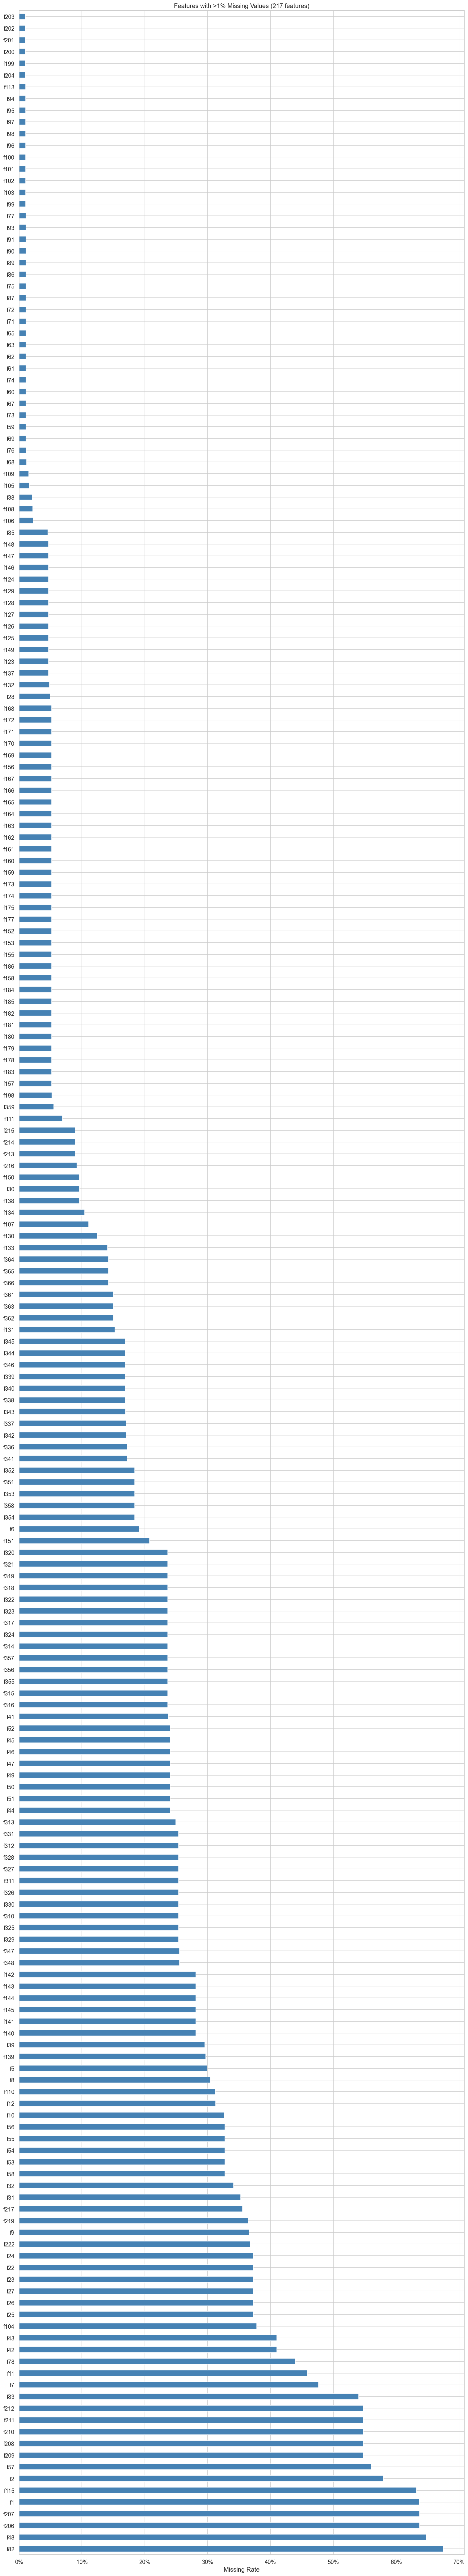

Features with any null:  217
Features with >50% null: 14


In [4]:
# Missing value overview
missing = df.isnull().mean().sort_values(ascending=False)
missing_sig = missing[missing > 0.01]

fig, ax = plt.subplots(figsize=(14, max(4, len(missing_sig)*0.35)))
missing_sig.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing Rate')
ax.set_title(f'Features with >1% Missing Values ({len(missing_sig)} features)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.show()
print(f'Features with any null:  {(missing > 0).sum()}')
print(f'Features with >50% null: {(missing > 0.5).sum()}')

---
## 1. Target Variable Analysis

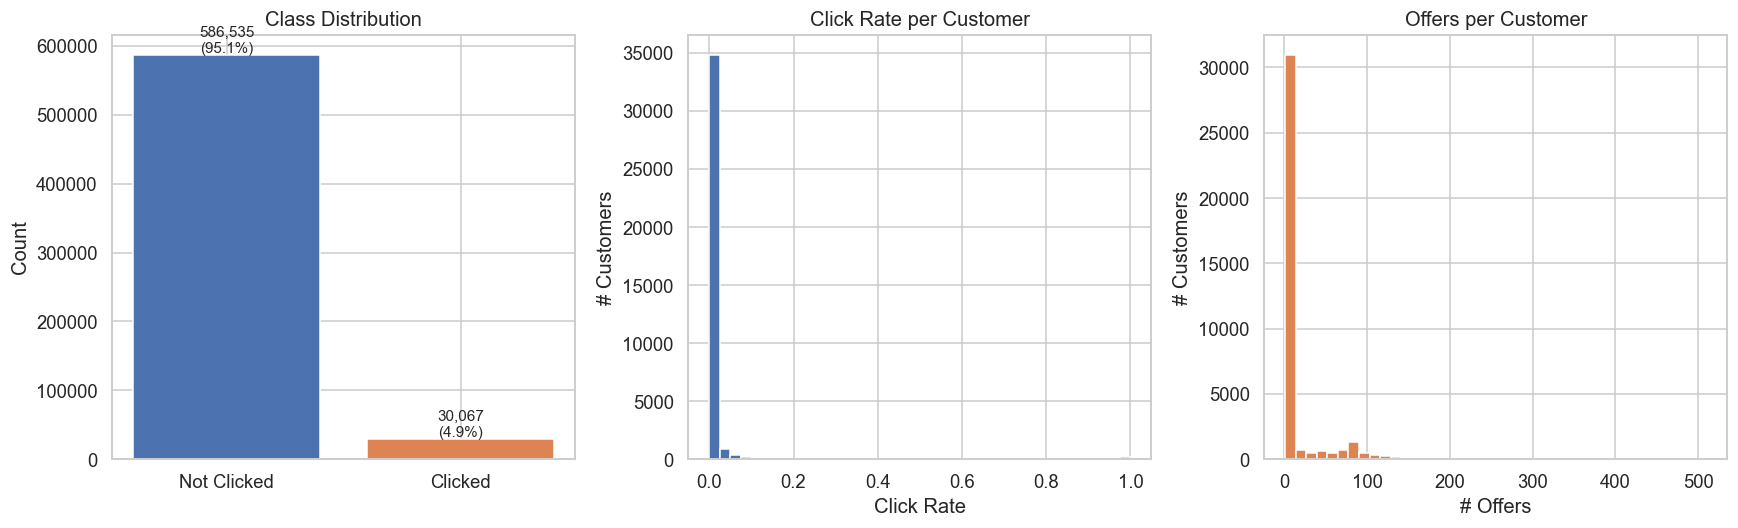

Unique customers: 37,240 | Unique offers: 751
Avg offers/customer: 16.6 | Median CTR/customer: 0.0000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df['y'].value_counts()
axes[0].bar(['Not Clicked', 'Clicked'], [counts.get(0,0), counts.get(1,0)], color=['#4C72B0','#DD8452'])
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 3000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')

customer_ctr = df.groupby('id2')['y'].agg(['mean','count']).reset_index()
customer_ctr.columns = ['id2','ctr','n_offers']
axes[1].hist(customer_ctr['ctr'], bins=40, color='#4C72B0', edgecolor='white')
axes[1].set_title('Click Rate per Customer'); axes[1].set_xlabel('Click Rate'); axes[1].set_ylabel('# Customers')

axes[2].hist(customer_ctr['n_offers'], bins=40, color='#DD8452', edgecolor='white')
axes[2].set_title('Offers per Customer'); axes[2].set_xlabel('# Offers'); axes[2].set_ylabel('# Customers')

plt.tight_layout(); plt.show()
print(f'Unique customers: {df["id2"].nunique():,} | Unique offers: {df["id3"].nunique():,}')
print(f'Avg offers/customer: {customer_ctr["n_offers"].mean():.1f} | Median CTR/customer: {customer_ctr["ctr"].median():.4f}')

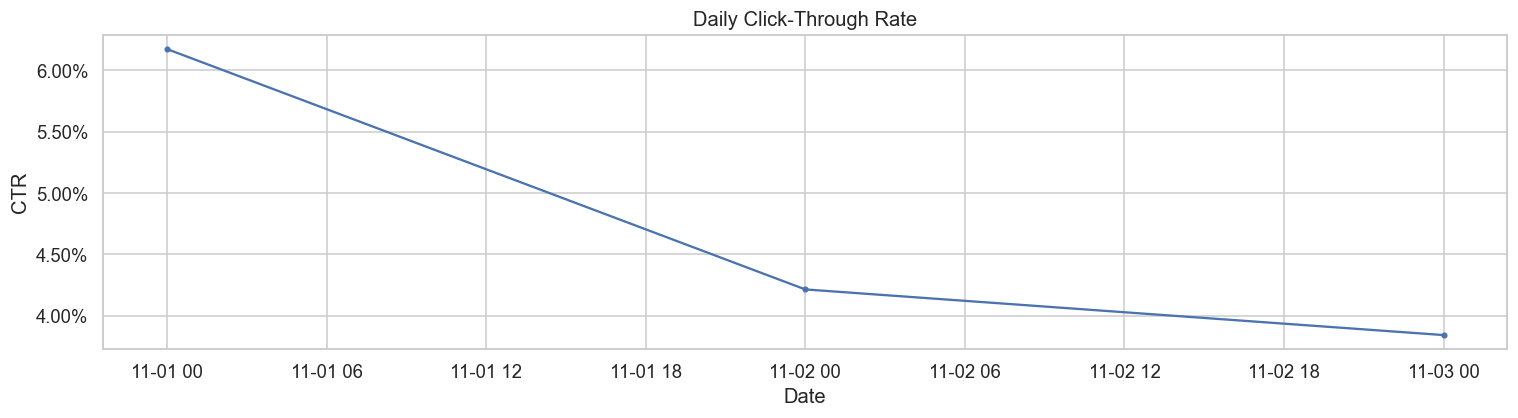

In [6]:
# Click rate over time
if 'id5' in df.columns:
    df['_dt'] = pd.to_datetime(df['id5'], errors='coerce')
    daily = df.groupby(df['_dt'].dt.date)['y'].mean()
    if len(daily) > 1:
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(daily.index, daily.values, marker='o', ms=3, lw=1.5, color='#4C72B0')
        ax.set_title('Daily Click-Through Rate'); ax.set_xlabel('Date'); ax.set_ylabel('CTR')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        plt.tight_layout(); plt.show()
    df.drop(columns=['_dt'], inplace=True)

---
## 2. Customer Features
### 2a. Interest Scores (f1–f12)

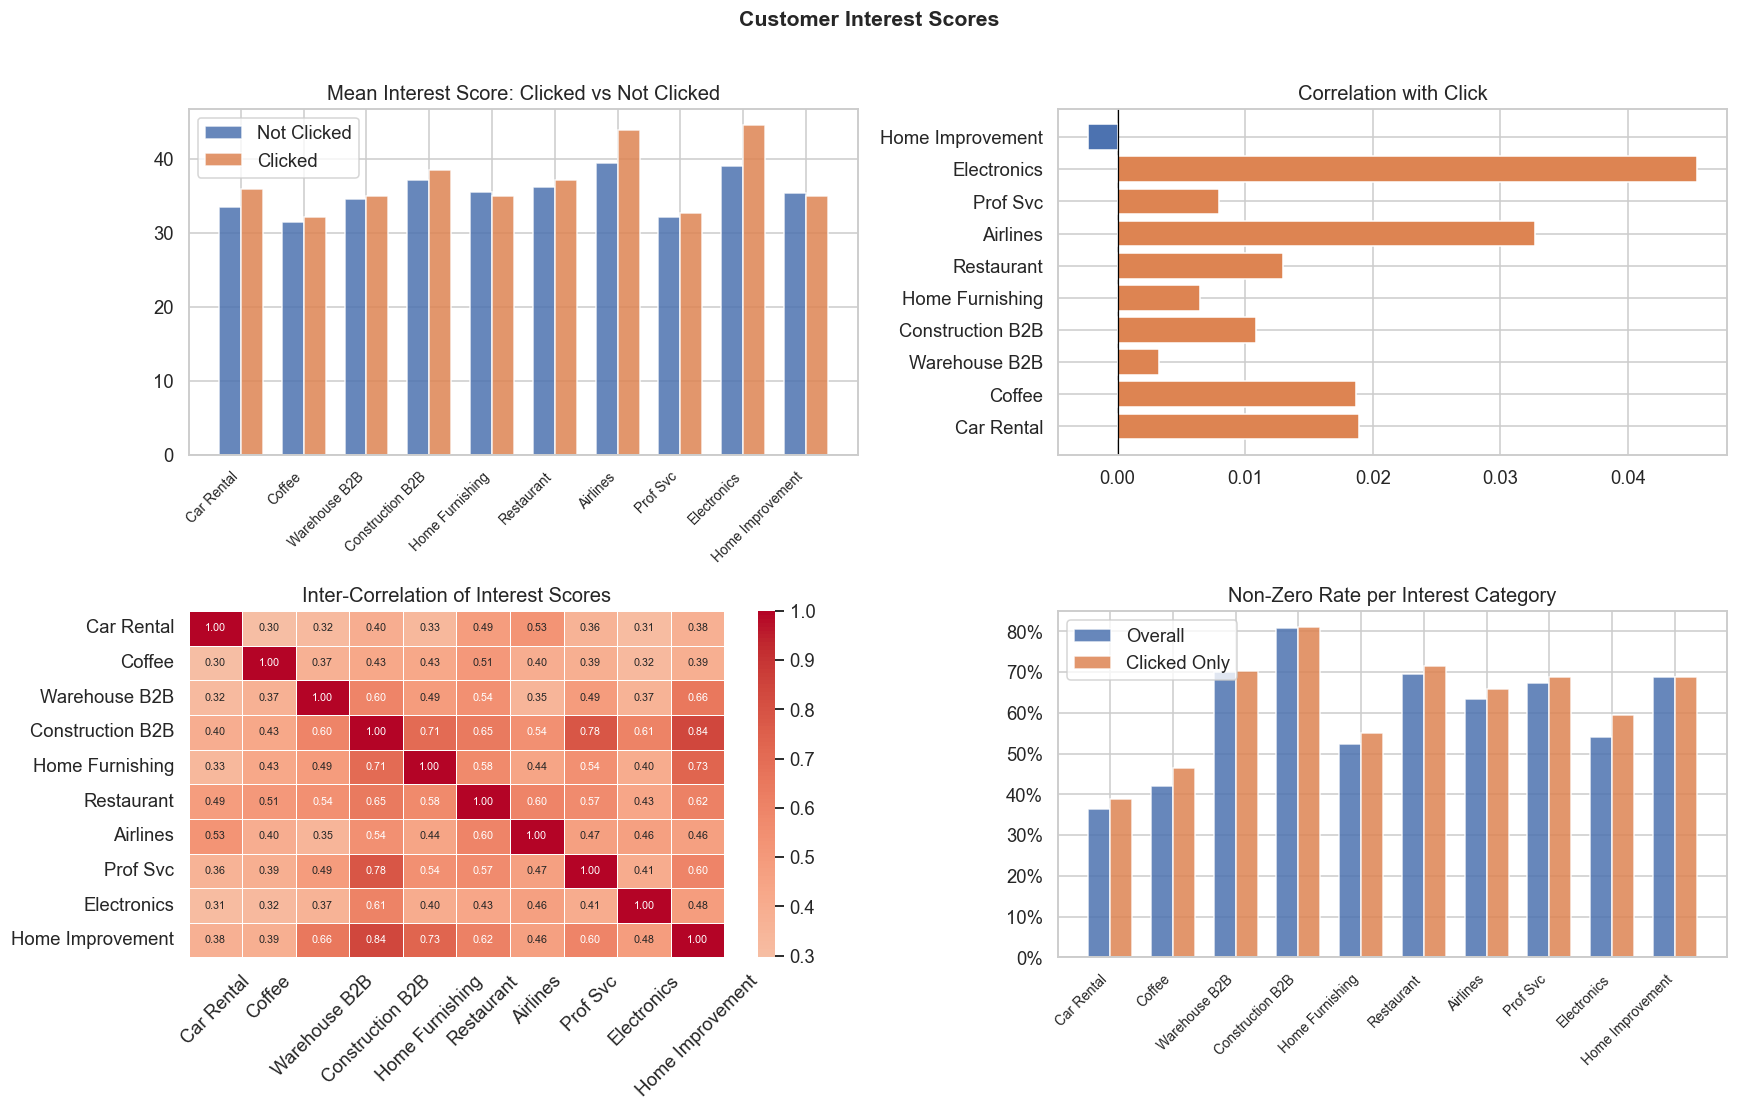

In [7]:
interest_labels = {
    'f1':'Car Rental','f2':'Coffee','f3':'Shipping B2B','f4':'Photography',
    'f5':'Warehouse B2B','f6':'Construction B2B','f7':'Home Furnishing',
    'f8':'Restaurant','f9':'Airlines','f10':'Prof Svc','f11':'Electronics','f12':'Home Improvement'
}

if INTEREST_COLS:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    x = np.arange(len(INTEREST_COLS)); w = 0.35
    xlbls = [interest_labels.get(c,c) for c in INTEREST_COLS]

    ax = axes[0,0]
    ax.bar(x-w/2, df[df['y']==0][INTEREST_COLS].mean().values, w, label='Not Clicked', color='#4C72B0', alpha=0.85)
    ax.bar(x+w/2, df[df['y']==1][INTEREST_COLS].mean().values, w, label='Clicked',     color='#DD8452', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=45, ha='right', fontsize=9)
    ax.set_title('Mean Interest Score: Clicked vs Not Clicked'); ax.legend()

    ax = axes[0,1]
    corrs = [stats.pointbiserialr(df[c].fillna(0), df['y'])[0] for c in INTEREST_COLS]
    ax.barh(xlbls, corrs, color=['#DD8452' if v>0 else '#4C72B0' for v in corrs])
    ax.axvline(0, color='black', lw=0.8); ax.set_title('Correlation with Click')

    ax = axes[1,0]
    int_corr = df[INTEREST_COLS].fillna(0).corr()
    int_corr.columns = xlbls; int_corr.index = xlbls
    sns.heatmap(int_corr, ax=ax, cmap='coolwarm', center=0, annot=True, fmt='.2f',
                annot_kws={'size':7}, linewidths=0.5)
    ax.set_title('Inter-Correlation of Interest Scores'); ax.tick_params(axis='x', rotation=45)

    ax = axes[1,1]
    ax.bar(x-w/2, (df[INTEREST_COLS]>0).mean().values,         w, label='Overall',      color='#4C72B0', alpha=0.85)
    ax.bar(x+w/2, (df[df['y']==1][INTEREST_COLS]>0).mean().values, w, label='Clicked Only', color='#DD8452', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=45, ha='right', fontsize=9)
    ax.set_title('Non-Zero Rate per Interest Category')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend()

    plt.suptitle('Customer Interest Scores', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

### 2b. Digital Engagement — Channel Usage

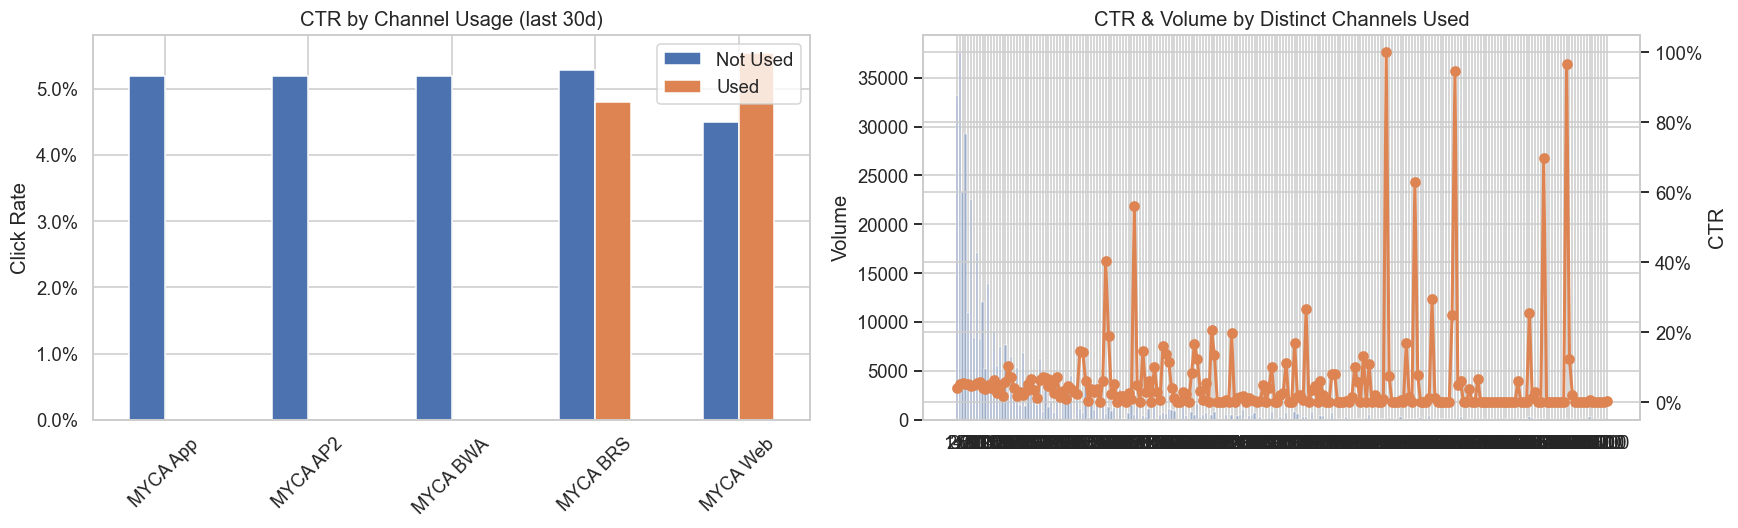

In [8]:
channel_labels = {'f22':'Distinct Channels','f23':'MYCA App','f24':'MYCA AP2',
                   'f25':'MYCA BWA','f26':'MYCA BRS','f27':'MYCA Web'}

binary_ch = [c for c in DIGITAL_CHANNEL_COLS if c != 'f22']
if binary_ch:
    ctr_ch = {}
    for c in binary_ch:
        v0 = df[df[c]==0]['y'].mean() if (df[c]==0).any() else np.nan
        v1 = df[df[c]==1]['y'].mean() if (df[c]==1).any() else np.nan
        ctr_ch[channel_labels.get(c,c)] = [v0, v1]
    ctr_ch_df = pd.DataFrame(ctr_ch, index=['Not Used','Used']).T.dropna(how='all')

    if not ctr_ch_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        ctr_ch_df.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white')
        axes[0].set_title('CTR by Channel Usage (last 30d)'); axes[0].set_ylabel('Click Rate')
        axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axes[0].tick_params(axis='x', rotation=45); axes[0].legend()

        if 'f22' in df.columns:
            ctr_ch_cnt = df.groupby('f22')['y'].mean()
            cnt_ch_cnt = df['f22'].value_counts().sort_index()
            ax2 = axes[1].twinx()
            axes[1].bar(cnt_ch_cnt.index.astype(str), cnt_ch_cnt.values, color='#4C72B0', alpha=0.4)
            ax2.plot(ctr_ch_cnt.index.astype(str), ctr_ch_cnt.values, color='#DD8452', marker='o', lw=2)
            axes[1].set_title('CTR & Volume by Distinct Channels Used')
            axes[1].set_ylabel('Volume'); ax2.set_ylabel('CTR')
            ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        else:
            axes[1].set_visible(False)
        plt.tight_layout(); plt.show()

### 2c. Page Time Spent (30d)

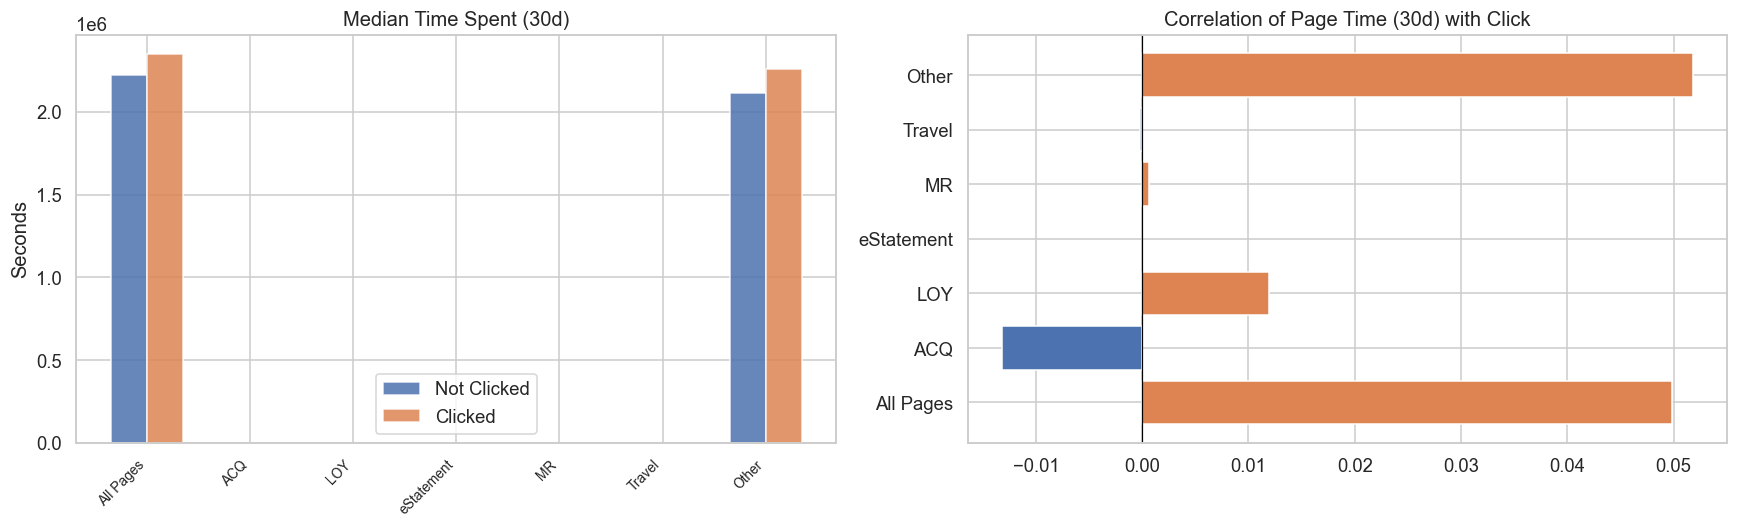

In [9]:
page_time_labels = {'f59':'All Pages','f60':'ACQ','f61':'LOY','f62':'eStatement',
                    'f63':'MR','f64':'OCE','f65':'Travel','f66':'Prepaid','f67':'Other'}

if PAGE_TIME_30D:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = np.arange(len(PAGE_TIME_30D)); w = 0.35
    xlbls = [page_time_labels.get(c,c) for c in PAGE_TIME_30D]

    ax = axes[0]
    ax.bar(x-w/2, df[df['y']==0][PAGE_TIME_30D].median().values, w, label='Not Clicked', color='#4C72B0', alpha=0.85)
    ax.bar(x+w/2, df[df['y']==1][PAGE_TIME_30D].median().values, w, label='Clicked',     color='#DD8452', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=45, ha='right', fontsize=9)
    ax.set_title('Median Time Spent (30d)'); ax.set_ylabel('Seconds'); ax.legend()

    ax = axes[1]
    corrs_pt = [stats.pointbiserialr(df[c].fillna(0), df['y'])[0] for c in PAGE_TIME_30D]
    ax.barh(xlbls, corrs_pt, color=['#DD8452' if v>0 else '#4C72B0' for v in corrs_pt])
    ax.axvline(0, color='black', lw=0.8); ax.set_title('Correlation of Page Time (30d) with Click')
    plt.tight_layout(); plt.show()

### 2d. Customer Spend Behavior

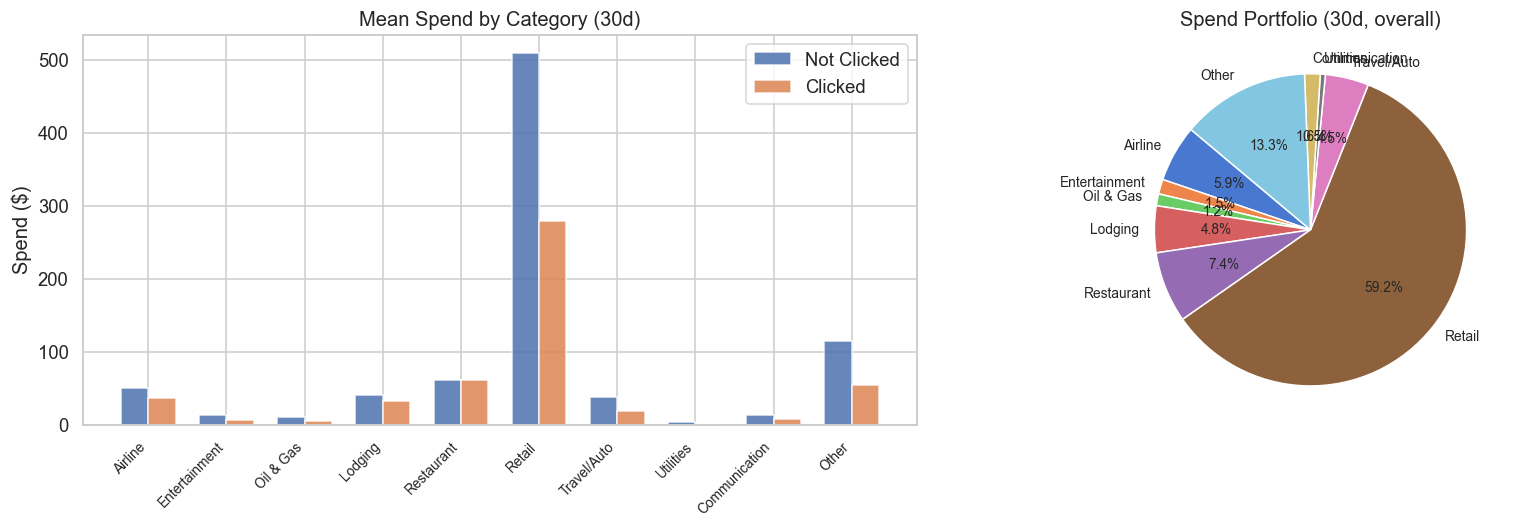

In [10]:
spend_30d_labels = {
    'f152':'Airline','f153':'Entertainment','f154':'Insurance/Fin','f155':'Oil & Gas',
    'f156':'Lodging','f157':'Restaurant','f158':'Retail','f159':'Travel/Auto',
    'f160':'Utilities','f161':'Communication','f162':'Other'
}

if SPEND_30D_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = np.arange(len(SPEND_30D_COLS)); w = 0.35
    xlbls = [spend_30d_labels.get(c,c) for c in SPEND_30D_COLS]

    ax = axes[0]
    ax.bar(x-w/2, df[df['y']==0][SPEND_30D_COLS].mean().values, w, label='Not Clicked', color='#4C72B0', alpha=0.85)
    ax.bar(x+w/2, df[df['y']==1][SPEND_30D_COLS].mean().values, w, label='Clicked',     color='#DD8452', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=45, ha='right', fontsize=9)
    ax.set_title('Mean Spend by Category (30d)'); ax.set_ylabel('Spend ($)'); ax.legend()

    ax = axes[1]
    om = df[SPEND_30D_COLS].mean(); om = om[om > 0]
    if not om.empty:
        ax.pie(om.values, labels=[spend_30d_labels.get(c,c) for c in om.index],
               autopct='%1.1f%%', startangle=140, textprops={'fontsize':9})
        ax.set_title('Spend Portfolio (30d, overall)')
    plt.tight_layout(); plt.show()

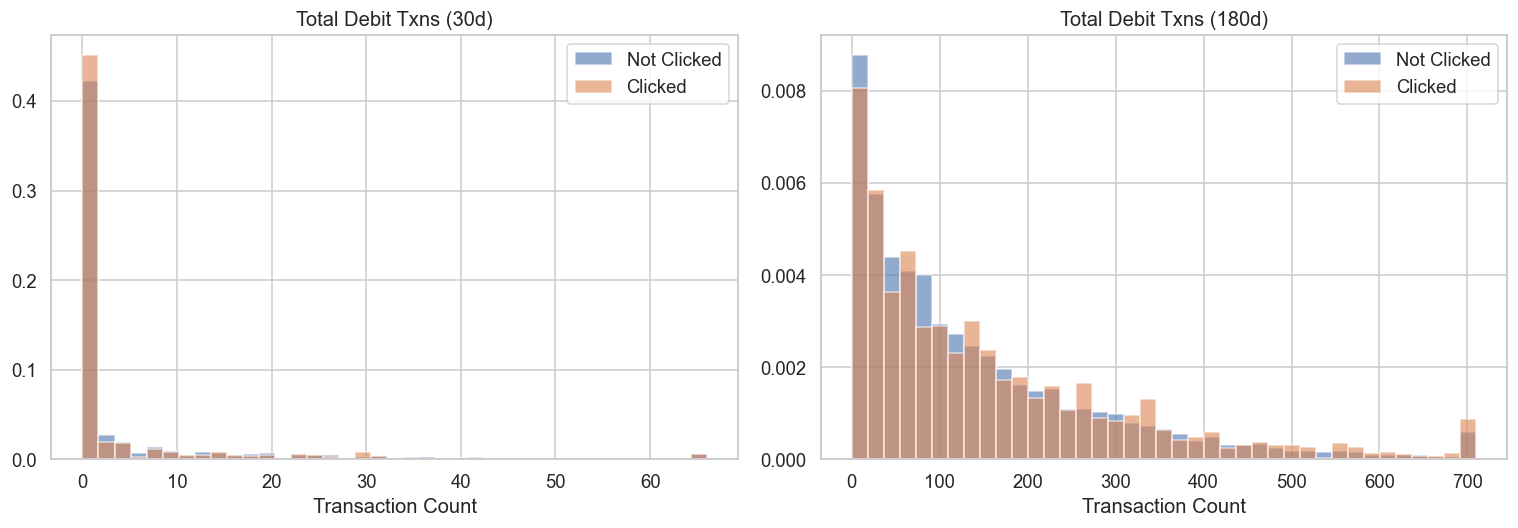

In [11]:
txn_cols = avail(['f185','f186'])
txn_labels = {'f185':'Total Debit Txns (30d)', 'f186':'Total Debit Txns (180d)'}

if txn_cols:
    fig, axes = plt.subplots(1, len(txn_cols), figsize=(7*len(txn_cols), 5))
    if len(txn_cols) == 1: axes = [axes]
    for ax, col in zip(axes, txn_cols):
        p99 = df[col].dropna().quantile(0.99)
        bins = np.linspace(0, p99, 40)
        ax.hist(df[df['y']==0][col].dropna().clip(upper=p99), bins=bins, alpha=0.6, label='Not Clicked', color='#4C72B0', density=True)
        ax.hist(df[df['y']==1][col].dropna().clip(upper=p99), bins=bins, alpha=0.6, label='Clicked',     color='#DD8452', density=True)
        ax.set_title(txn_labels.get(col,col)); ax.set_xlabel('Transaction Count'); ax.legend()
    plt.tight_layout(); plt.show()

### 2e. Loyalty & Miles

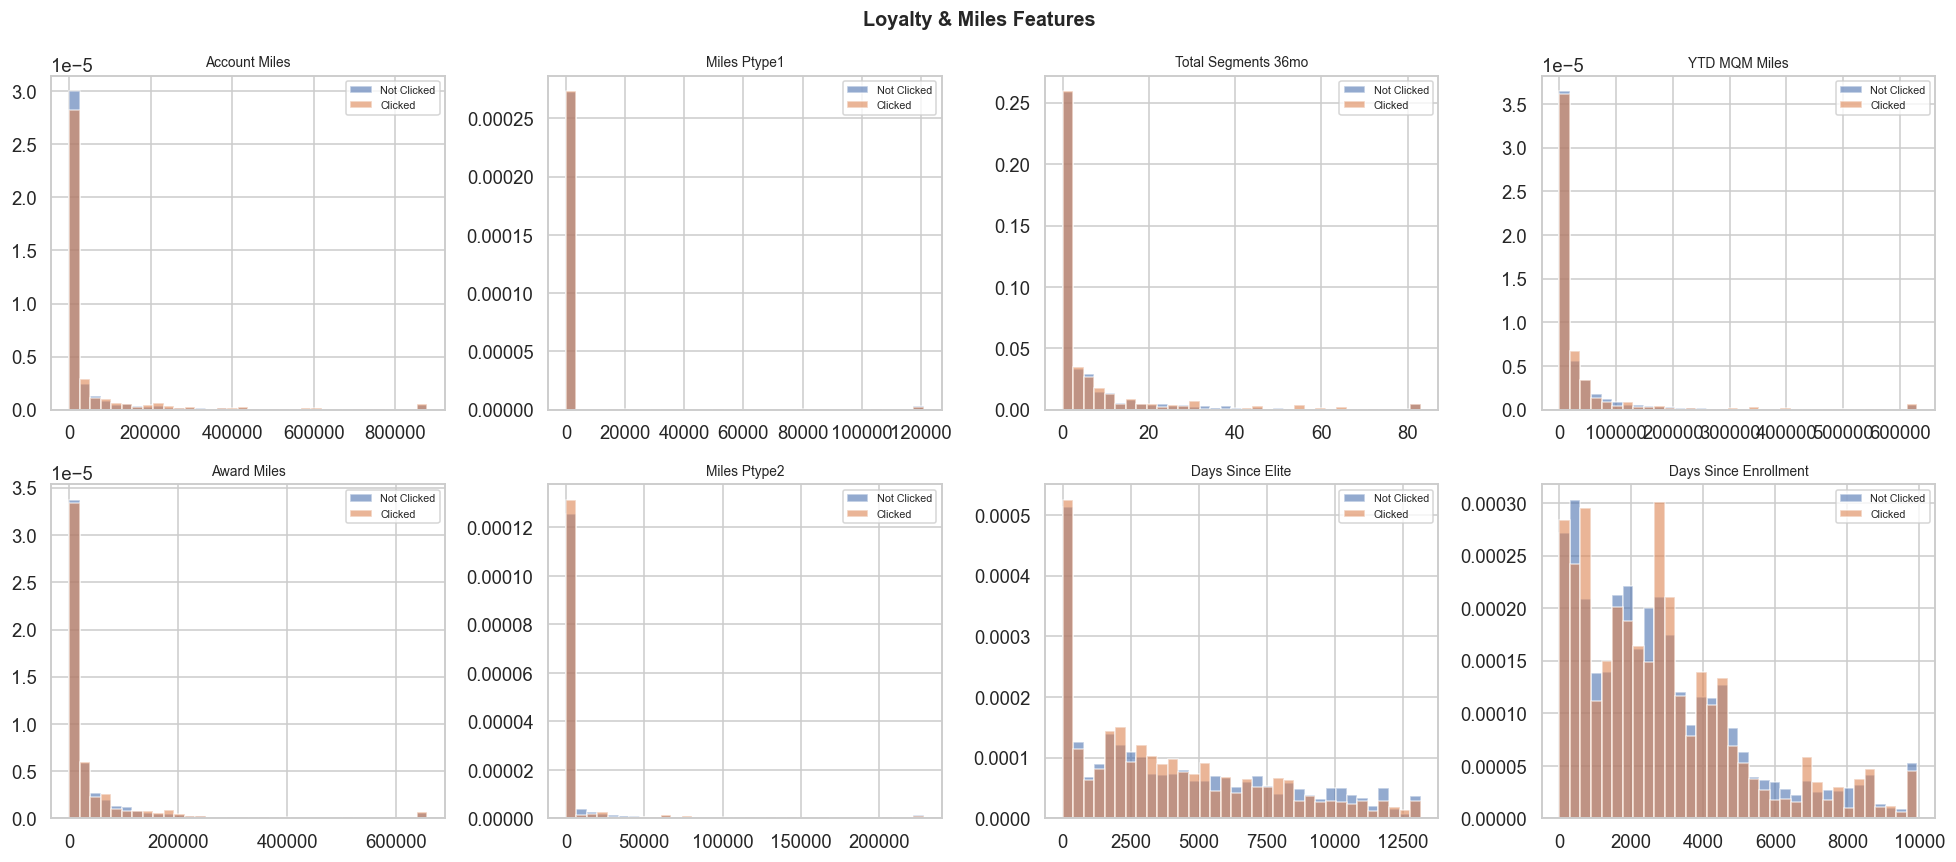

In [12]:
loyalty_labels_d = {'f43':'Account Miles','f44':'Miles Ptype1','f45':'Total Segments 36mo',
                    'f46':'YTD MQM Miles','f47':'Award Miles','f49':'Miles Ptype2',
                    'f51':'Days Since Elite','f58':'Days Since Enrollment'}

if LOYALTY_NUM_COLS:
    ncols = 4; nrows = (len(LOYALTY_NUM_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(LOYALTY_NUM_COLS):
        ax = axes[i]
        p99 = df[col].dropna().quantile(0.99)
        bins = np.linspace(0, p99, 35)
        ax.hist(df[df['y']==0][col].dropna().clip(upper=p99), bins=bins, alpha=0.6, label='Not Clicked', color='#4C72B0', density=True)
        ax.hist(df[df['y']==1][col].dropna().clip(upper=p99), bins=bins, alpha=0.6, label='Clicked',     color='#DD8452', density=True)
        ax.set_title(loyalty_labels_d.get(col,col), fontsize=9); ax.legend(fontsize=7)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('Loyalty & Miles Features', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

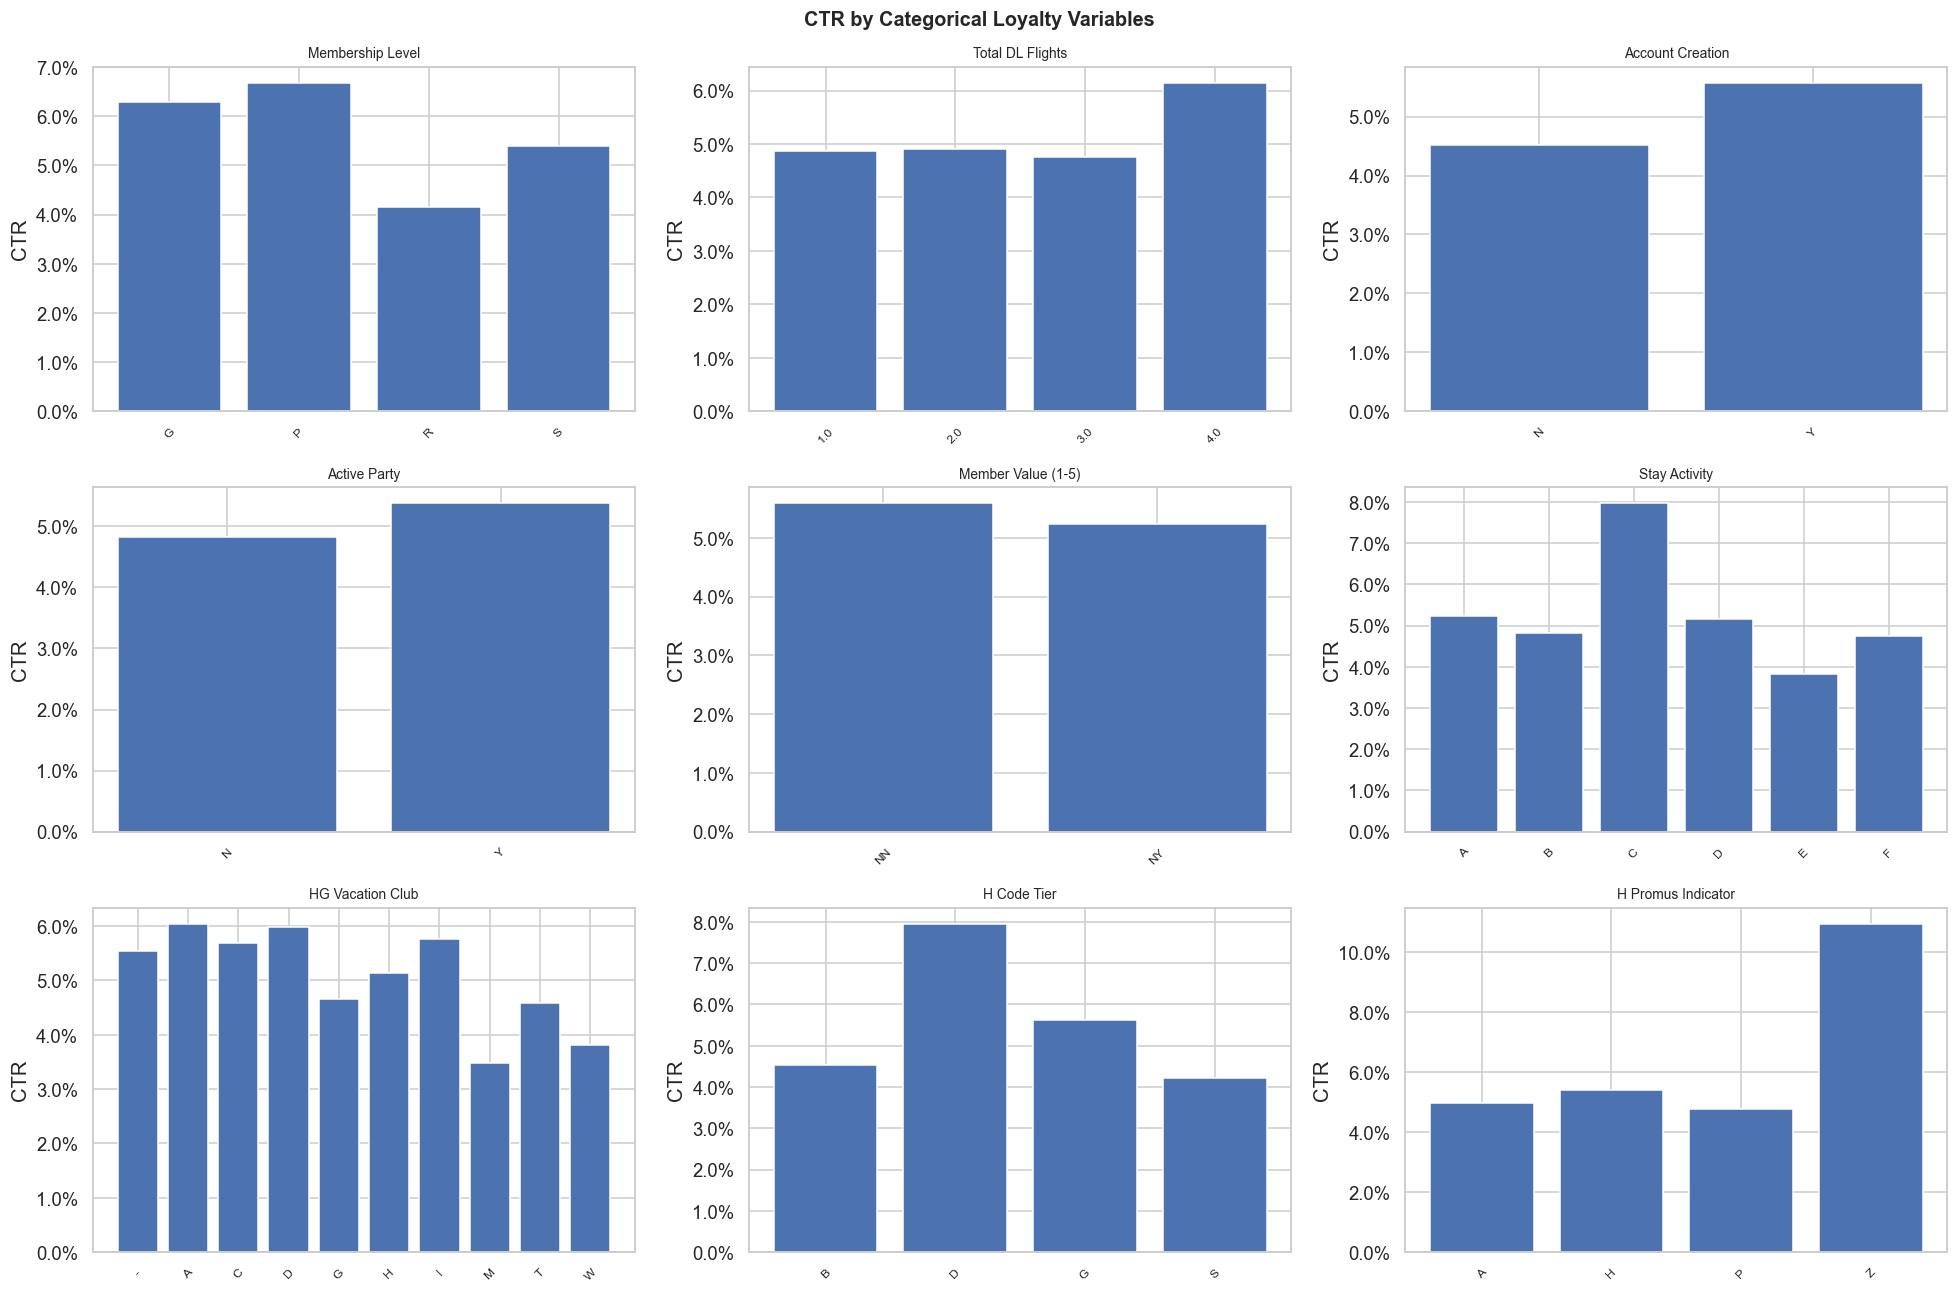

In [13]:
cat_loy_labels = {'f42':'Membership Level','f48':'Total DL Flights','f50':'Account Creation',
                   'f52':'Active Party','f53':'Member Value (1-5)','f54':'Stay Activity',
                   'f55':'HG Vacation Club','f56':'H Code Tier','f57':'H Promus Indicator'}

if LOYALTY_CAT_COLS:
    ncols = 3; nrows = (len(LOYALTY_CAT_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(LOYALTY_CAT_COLS):
        ax = axes[i]
        ctr_cat = df.groupby(col)['y'].mean()
        top10 = df[col].value_counts().head(10).index
        ctr_plot = ctr_cat[ctr_cat.index.isin(top10)]
        if not ctr_plot.empty:
            ax.bar(ctr_plot.index.astype(str), ctr_plot.values, color='#4C72B0', edgecolor='white')
        ax.set_title(cat_loy_labels.get(col,col), fontsize=9); ax.set_ylabel('CTR')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('CTR by Categorical Loyalty Variables', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 3. Offer Features
### 3a. Category Distribution & CTR

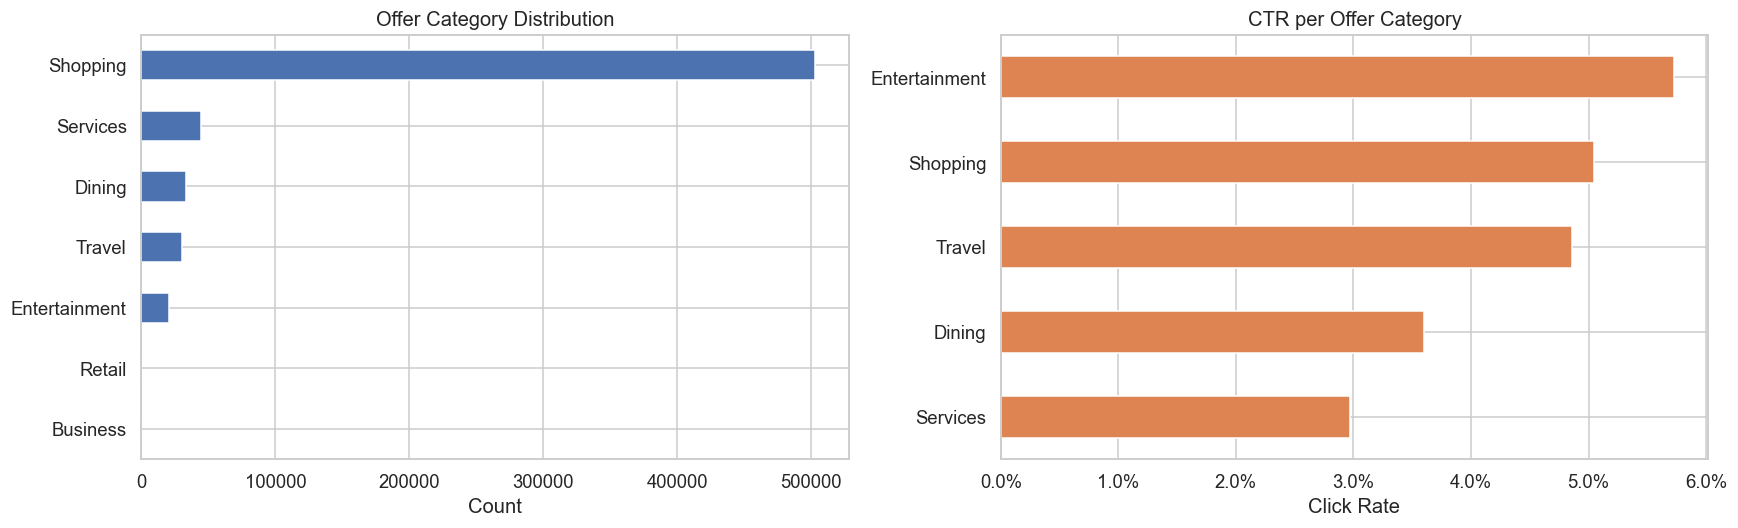

In [14]:
cat_ohe_labels = {'f226':'Business','f227':'Dining','f228':'Entertainment',
                   'f229':'Retail','f230':'Services','f231':'Shopping','f232':'Travel'}

if OHE_CATEGORY_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    cat_counts = df[OHE_CATEGORY_COLS].sum()
    cat_counts.index = [cat_ohe_labels.get(c,c) for c in cat_counts.index]
    cat_counts.sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0', edgecolor='white')
    axes[0].set_title('Offer Category Distribution'); axes[0].set_xlabel('Count')

    ctr_cat = {cat_ohe_labels.get(c,c): df[df[c]==1]['y'].mean()
               for c in OHE_CATEGORY_COLS if (df[c]==1).any()}
    if ctr_cat:
        pd.Series(ctr_cat).sort_values().plot(kind='barh', ax=axes[1], color='#DD8452', edgecolor='white')
    axes[1].set_title('CTR per Offer Category'); axes[1].set_xlabel('Click Rate')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.tight_layout(); plt.show()

### 3b. CTR & Impression Time-Window Trends

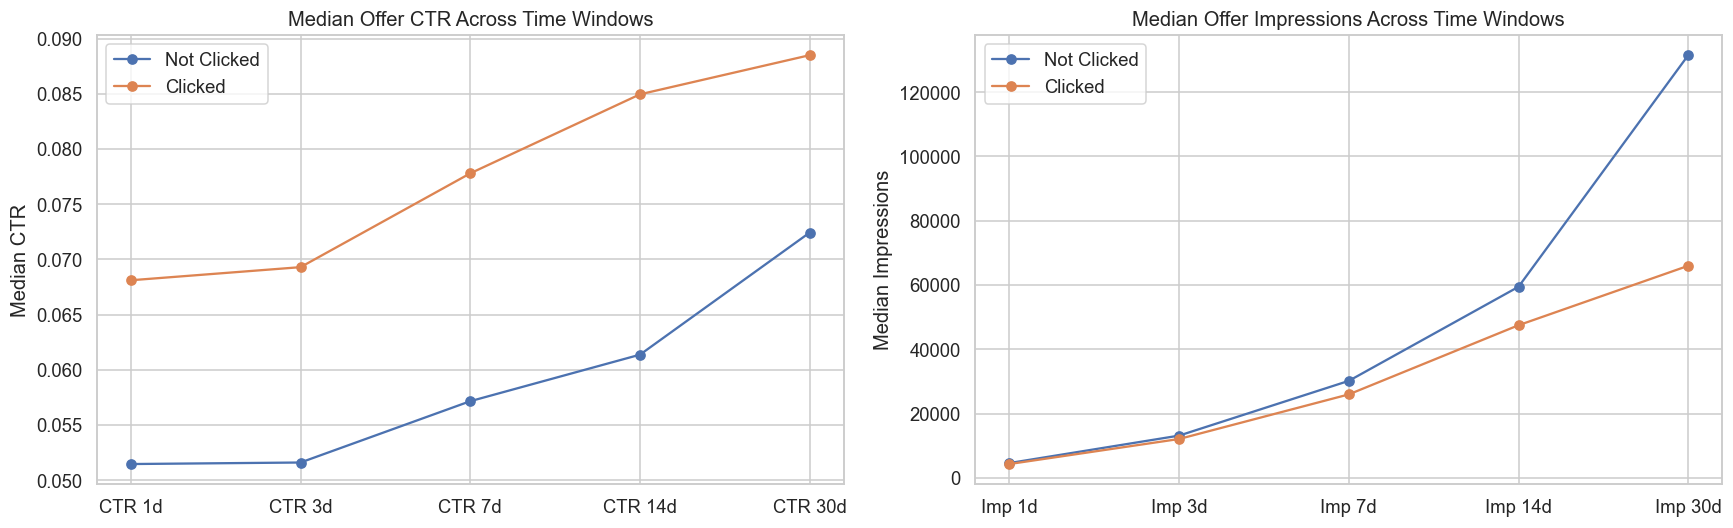

In [15]:
ctr_windows = ['f310','f311','f312','f313','f314']
ctr_win_lbl = ['CTR 1d','CTR 3d','CTR 7d','CTR 14d','CTR 30d']
imp_windows = ['f320','f321','f322','f323','f324']
imp_win_lbl = ['Imp 1d','Imp 3d','Imp 7d','Imp 14d','Imp 30d']

avail_ctr_w = avail(ctr_windows)
avail_imp_w = avail(imp_windows)

if avail_ctr_w or avail_imp_w:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    if avail_ctr_w:
        lbls = [ctr_win_lbl[ctr_windows.index(c)] for c in avail_ctr_w]
        axes[0].plot(lbls, [df[df['y']==0][c].median() for c in avail_ctr_w], marker='o', label='Not Clicked', color='#4C72B0')
        axes[0].plot(lbls, [df[df['y']==1][c].median() for c in avail_ctr_w], marker='o', label='Clicked',     color='#DD8452')
        axes[0].set_title('Median Offer CTR Across Time Windows'); axes[0].set_ylabel('Median CTR'); axes[0].legend()

    if avail_imp_w:
        lbls_i = [imp_win_lbl[imp_windows.index(c)] for c in avail_imp_w]
        axes[1].plot(lbls_i, [df[df['y']==0][c].median() for c in avail_imp_w], marker='o', label='Not Clicked', color='#4C72B0')
        axes[1].plot(lbls_i, [df[df['y']==1][c].median() for c in avail_imp_w], marker='o', label='Clicked',     color='#DD8452')
        axes[1].set_title('Median Offer Impressions Across Time Windows'); axes[1].set_ylabel('Median Impressions'); axes[1].legend()

    plt.tight_layout(); plt.show()

### 3c. Offer Value & Timing

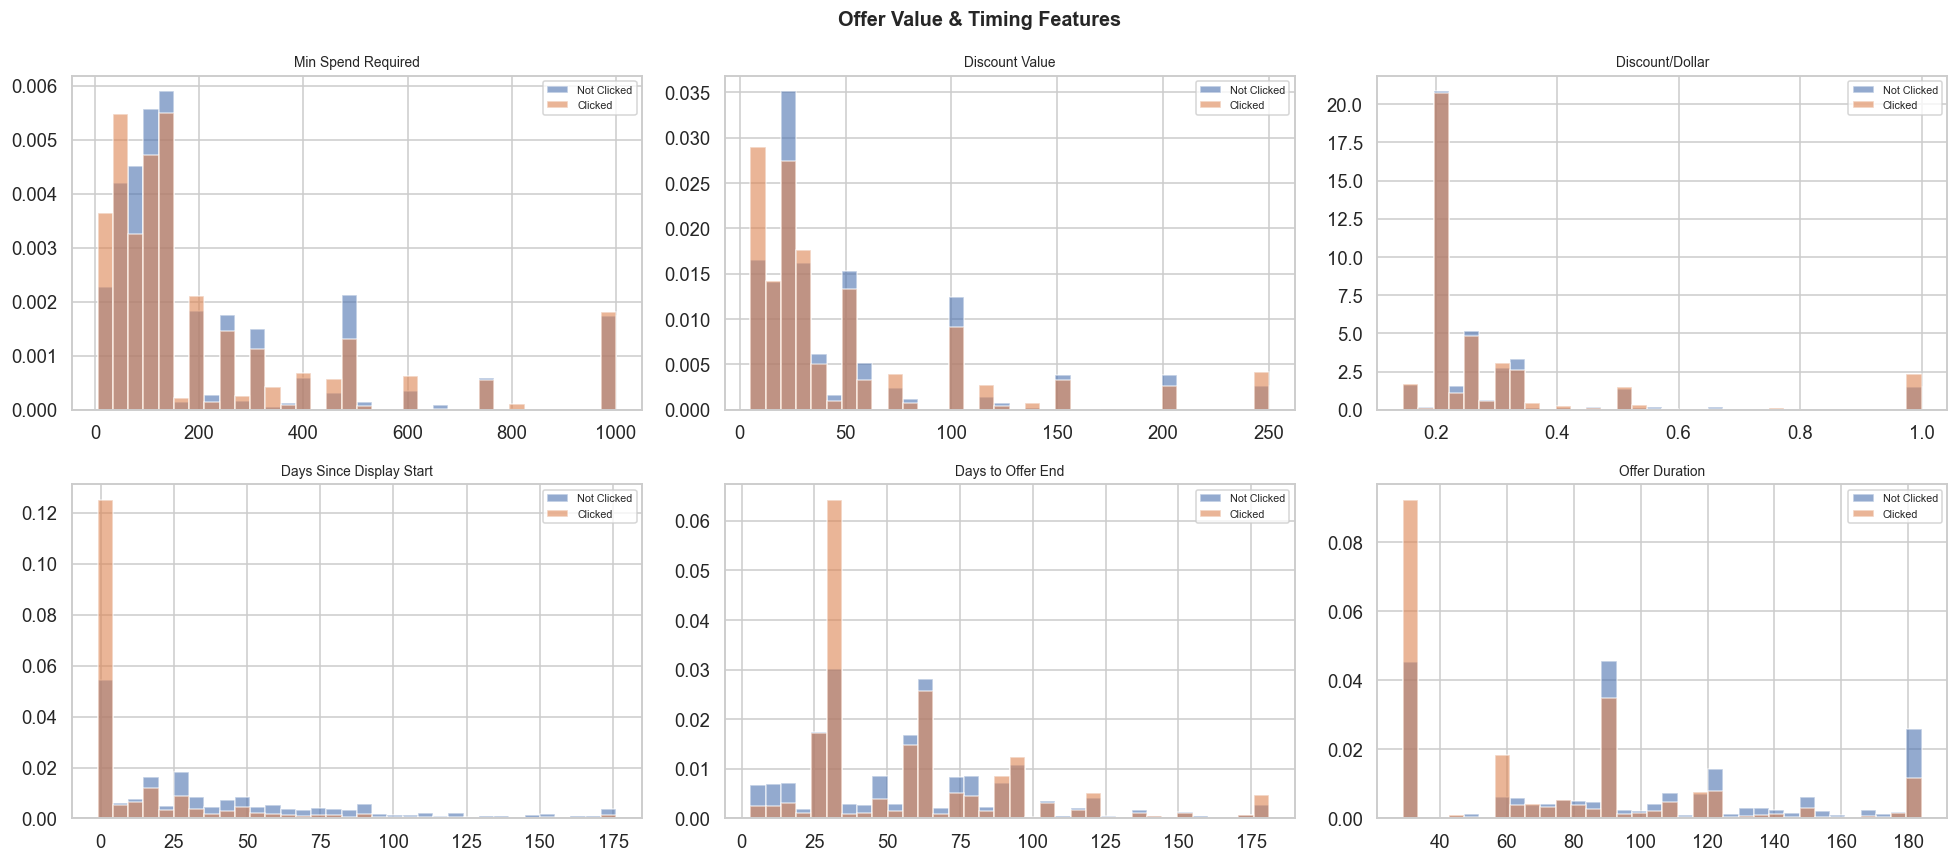

In [16]:
offer_val_labels = {'f217':'Min Spend Required','f376':'Discount Rate','f219':'Discount Value',
                    'f220':'MR Points','f221':'MR Points/Dollar','f222':'Discount/Dollar',
                    'f223':'Days Since Display Start','f224':'Days to Offer End','f225':'Offer Duration'}

if OFFER_MERIT_COLS:
    ncols = 3; nrows = (len(OFFER_MERIT_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(OFFER_MERIT_COLS):
        ax = axes[i]
        vmin, vmax = df[col].dropna().quantile([0.01, 0.99])
        bins = np.linspace(vmin, vmax, 35)
        ax.hist(df[df['y']==0][col].dropna().clip(vmin, vmax), bins=bins, alpha=0.6, label='Not Clicked', color='#4C72B0', density=True)
        ax.hist(df[df['y']==1][col].dropna().clip(vmin, vmax), bins=bins, alpha=0.6, label='Clicked',     color='#DD8452', density=True)
        ax.set_title(offer_val_labels.get(col,col), fontsize=9); ax.legend(fontsize=7)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('Offer Value & Timing Features', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

### 3d. Offer Decay & Age Features

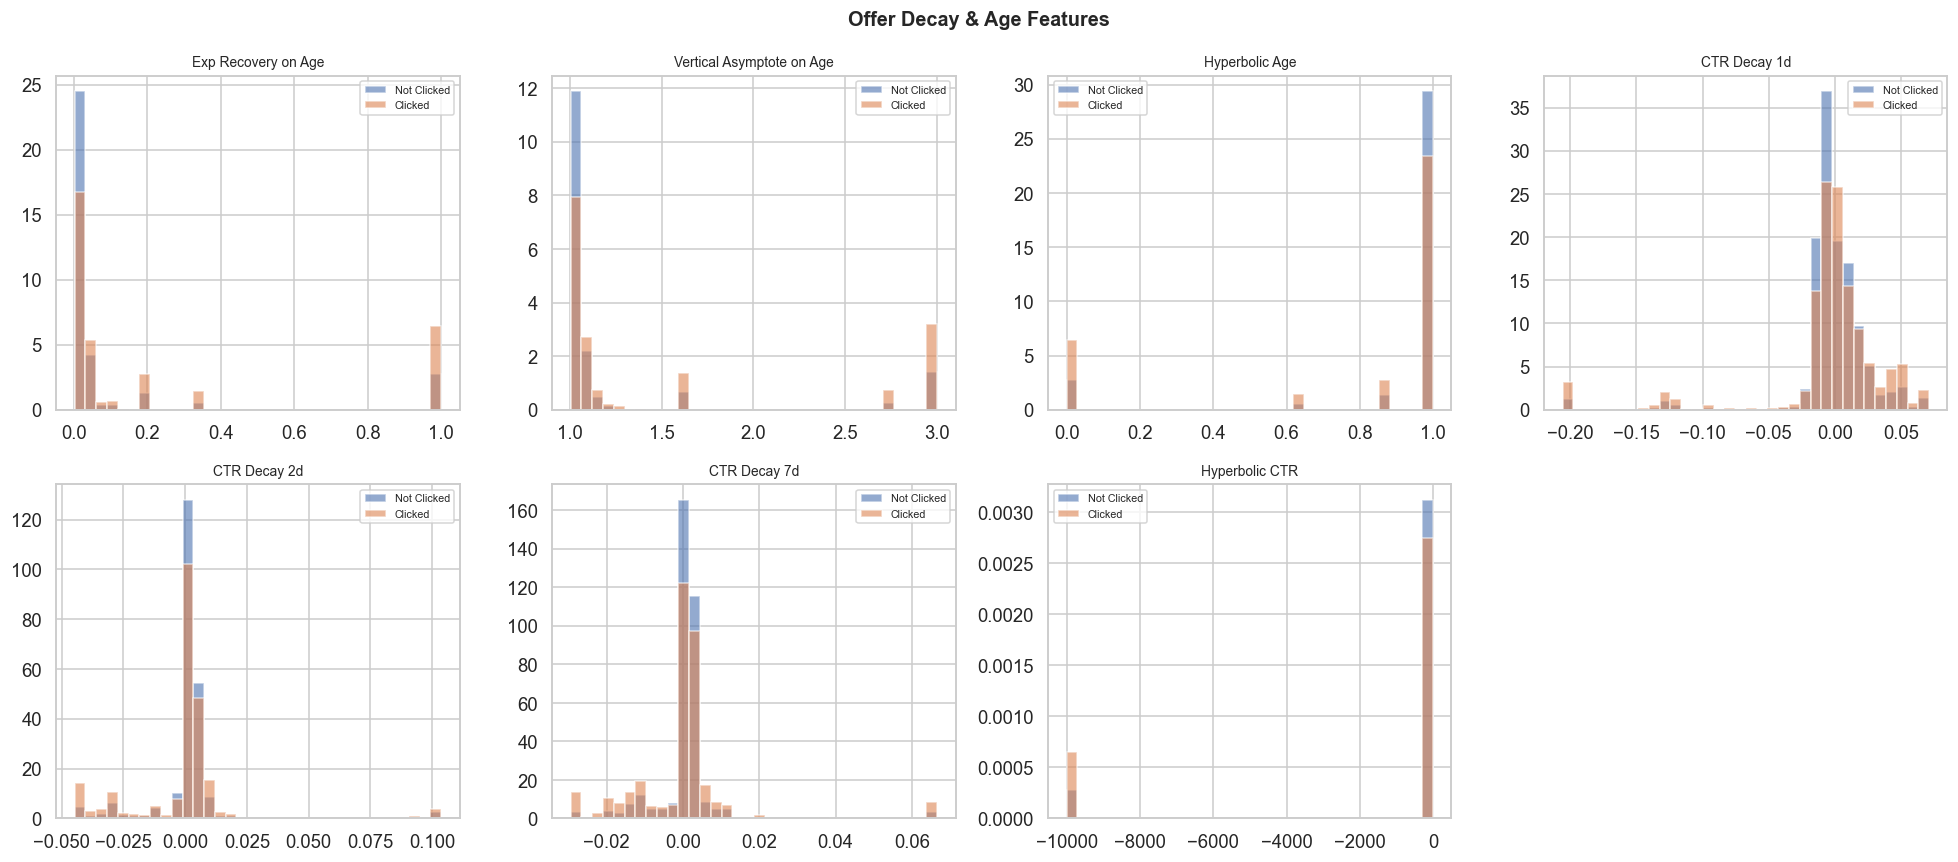

In [17]:
decay_labels = {'f351':'Exp Recovery on Age','f352':'Vertical Asymptote on Age',
                'f353':'Hyperbolic Age','f355':'CTR Decay 1d',
                'f356':'CTR Decay 2d','f357':'CTR Decay 7d','f358':'Hyperbolic CTR'}

if DECAY_COLS:
    ncols = 4; nrows = (len(DECAY_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(DECAY_COLS):
        ax = axes[i]
        p1, p99 = df[col].dropna().quantile([0.01, 0.99])
        bins = np.linspace(p1, p99, 35)
        ax.hist(df[df['y']==0][col].dropna().clip(p1, p99), bins=bins, alpha=0.6, label='Not Clicked', color='#4C72B0', density=True)
        ax.hist(df[df['y']==1][col].dropna().clip(p1, p99), bins=bins, alpha=0.6, label='Clicked',     color='#DD8452', density=True)
        ax.set_title(decay_labels.get(col,col), fontsize=9); ax.legend(fontsize=7)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('Offer Decay & Age Features', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 4. Customer × Offer Interaction Features
### 4a. Non-Merchant CTR by Offer Type

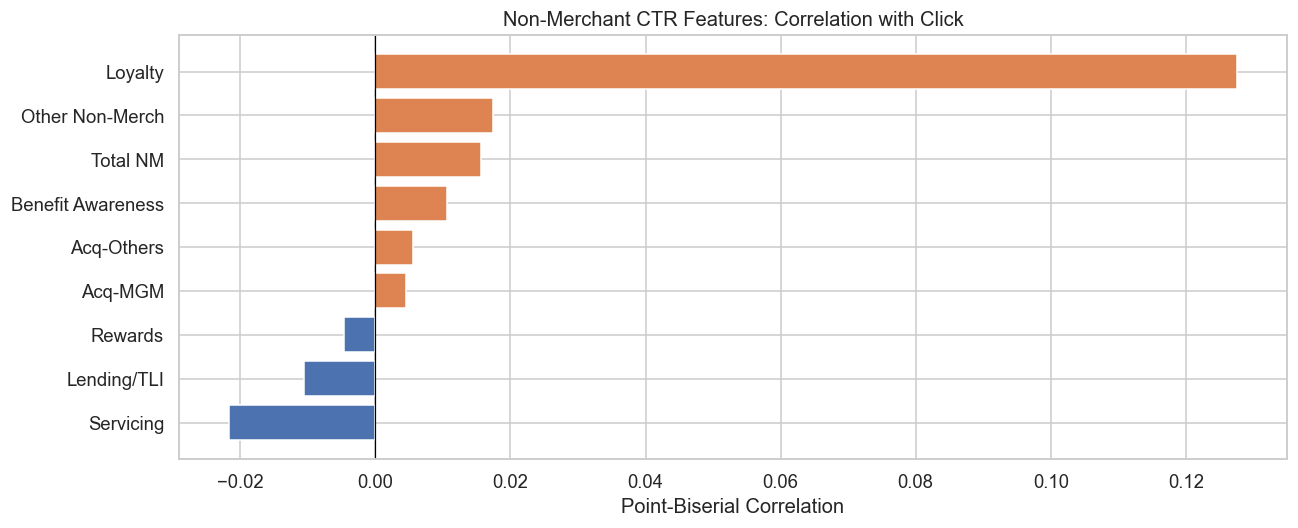

In [18]:
nm_ctr_labels = {'f104':'Rewards','f105':'Benefit Awareness','f106':'Acq-Others',
                'f107':'Acq-MGM','f108':'Loyalty','f109':'Lending/TLI',
                'f110':'Other Non-Merch','f111':'Servicing','f112':'Insurance','f113':'Total NM'}

if NON_MERCH_CTR_COLS:
    corrs_nm = sorted([(c, stats.pointbiserialr(df[c].fillna(0), df['y'])[0]) for c in NON_MERCH_CTR_COLS], key=lambda x: x[1])
    cols_nm, vals_nm = zip(*corrs_nm)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh([nm_ctr_labels.get(c,c) for c in cols_nm], vals_nm,
            color=['#DD8452' if v>0 else '#4C72B0' for v in vals_nm])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title('Non-Merchant CTR Features: Correlation with Click'); ax.set_xlabel('Point-Biserial Correlation')
    plt.tight_layout(); plt.show()

### 4b. Merchant CTR by Category

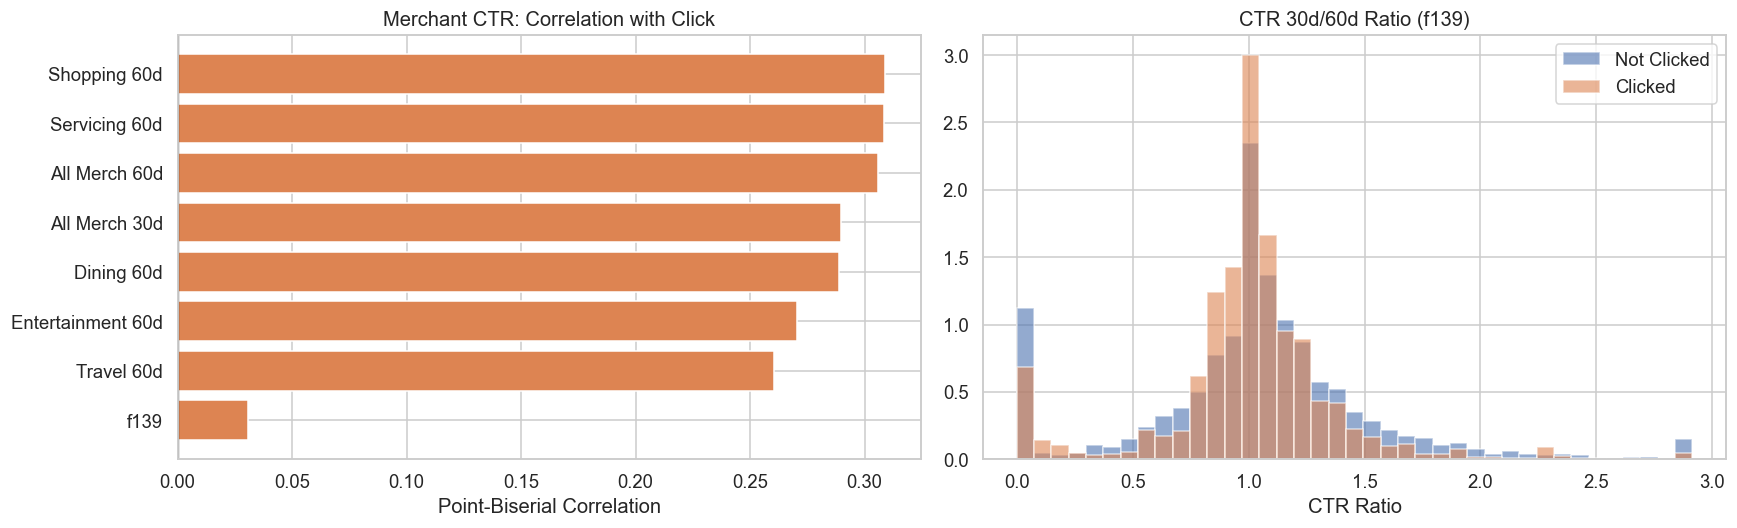

In [19]:
merch_ctr_labels = {'f130':'Dining 60d','f131':'Entertainment 60d','f132':'Shopping 60d',
                    'f133':'Travel 60d','f134':'Servicing 60d','f135':'Biz Expense 60d',
                    'f136':'Retail 60d','f137':'All Merch 60d','f138':'All Merch 30d'}

if MERCH_CTR_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    corrs_mc = sorted([(c, stats.pointbiserialr(df[c].fillna(0), df['y'])[0]) for c in MERCH_CTR_COLS], key=lambda x: x[1])
    cols_mc, vals_mc = zip(*corrs_mc)
    axes[0].barh([merch_ctr_labels.get(c,c) for c in cols_mc], vals_mc,
                 color=['#DD8452' if v>0 else '#4C72B0' for v in vals_mc])
    axes[0].axvline(0, color='black', lw=0.8)
    axes[0].set_title('Merchant CTR: Correlation with Click'); axes[0].set_xlabel('Point-Biserial Correlation')

    if 'f139' in df.columns:
        p99 = df['f139'].dropna().quantile(0.99); bins = np.linspace(0, p99, 40)
        axes[1].hist(df[df['y']==0]['f139'].dropna().clip(upper=p99), bins=bins, alpha=0.6, label='Not Clicked', color='#4C72B0', density=True)
        axes[1].hist(df[df['y']==1]['f139'].dropna().clip(upper=p99), bins=bins, alpha=0.6, label='Clicked',     color='#DD8452', density=True)
        axes[1].set_title('CTR 30d/60d Ratio (f139)'); axes[1].set_xlabel('CTR Ratio'); axes[1].legend()
    else:
        axes[1].set_visible(False)
    plt.tight_layout(); plt.show()

### 4c. Prior Engagement with Same Merchant

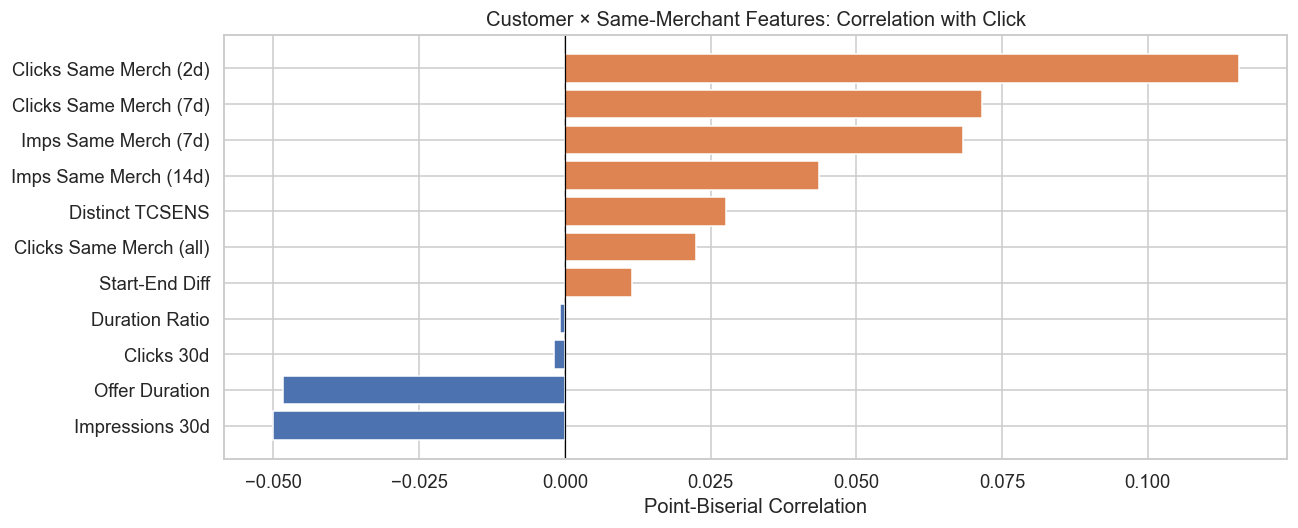

In [20]:
cm_merch_labels = {'f206':'Clicks 30d','f207':'Impressions 30d',
                   'f208':'Clicks Same Merch (2d)','f209':'Clicks Same Merch (7d)',
                   'f210':'Clicks Same Merch (all)','f211':'Imps Same Merch (7d)',
                   'f212':'Imps Same Merch (14d)','f213':'Distinct TCSENS',
                   'f214':'Start-End Diff','f215':'Offer Duration','f216':'Duration Ratio'}

if MERCH_CM_COLS:
    corrs_cmm = sorted([(c, stats.pointbiserialr(df[c].fillna(0), df['y'])[0]) for c in MERCH_CM_COLS], key=lambda x: x[1])
    cols_cmm, vals_cmm = zip(*corrs_cmm)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh([cm_merch_labels.get(c,c) for c in cols_cmm], vals_cmm,
            color=['#DD8452' if v>0 else '#4C72B0' for v in vals_cmm])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title('Customer × Same-Merchant Features: Correlation with Click'); ax.set_xlabel('Point-Biserial Correlation')
    plt.tight_layout(); plt.show()

### 4d. Industry CTR Alignment (Highest-Signal Features)

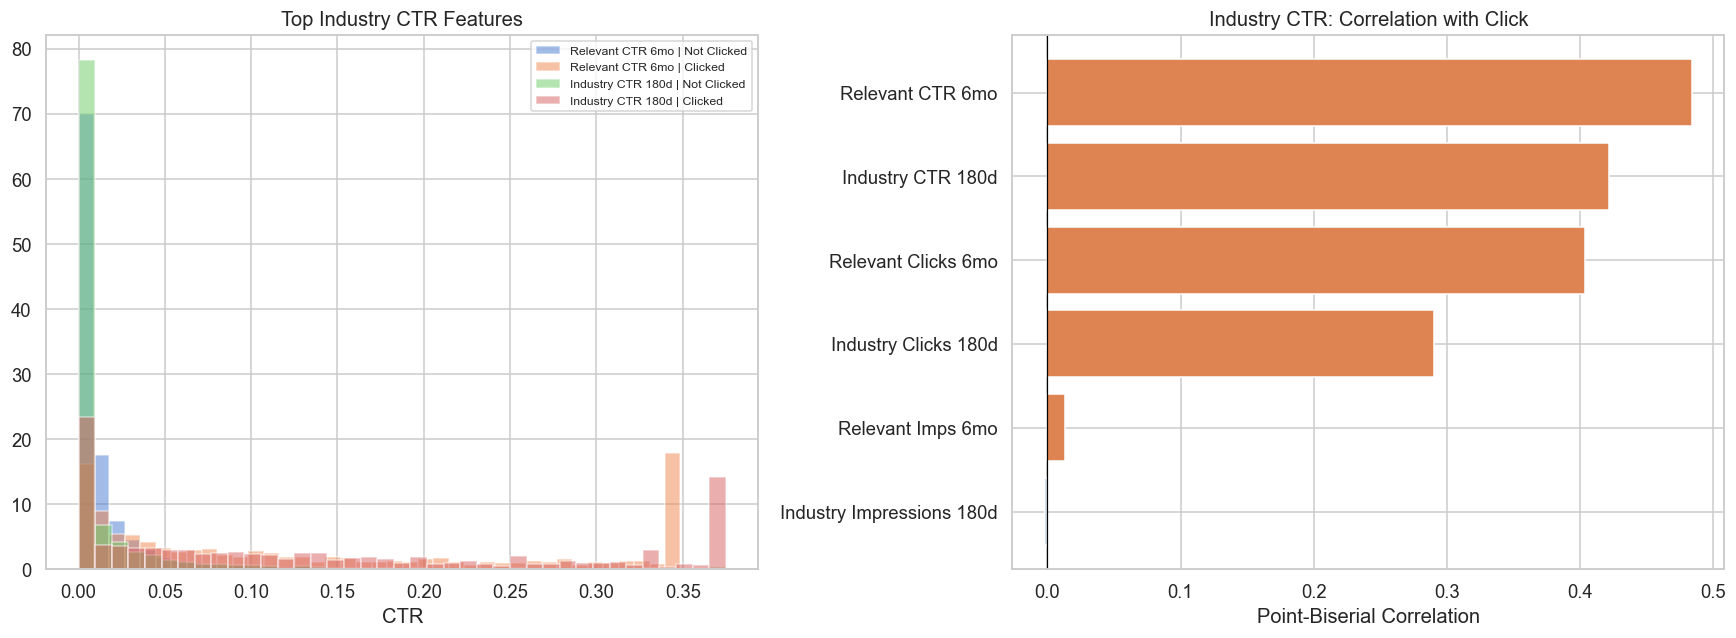

In [21]:
industry_labels = {'f361':'Industry Impressions 180d','f362':'Industry Clicks 180d',
                   'f363':'Industry CTR 180d','f364':'Relevant Imps 6mo',
                   'f365':'Relevant Clicks 6mo','f366':'Relevant CTR 6mo'}

if INDUSTRY_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    for col in [c for c in ['f366','f363'] if c in INDUSTRY_COLS]:
        p99 = df[col].dropna().quantile(0.99); bins = np.linspace(0, p99, 40)
        lbl = industry_labels.get(col,col)
        ax.hist(df[df['y']==0][col].dropna().clip(upper=p99), bins=bins, alpha=0.5, label=f'{lbl} | Not Clicked', density=True)
        ax.hist(df[df['y']==1][col].dropna().clip(upper=p99), bins=bins, alpha=0.5, label=f'{lbl} | Clicked',     density=True)
    ax.set_title('Top Industry CTR Features'); ax.set_xlabel('CTR'); ax.legend(fontsize=8)

    corrs_ind = sorted([(industry_labels.get(c,c), stats.pointbiserialr(df[c].fillna(0), df['y'])[0]) for c in INDUSTRY_COLS], key=lambda x: x[1])
    lbls_i, vals_i = zip(*corrs_ind)
    axes[1].barh(lbls_i, vals_i, color=['#DD8452' if v>0 else '#4C72B0' for v in vals_i])
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].set_title('Industry CTR: Correlation with Click'); axes[1].set_xlabel('Point-Biserial Correlation')
    plt.tight_layout(); plt.show()

### 4e. Context — Day of Week & Hour of Day

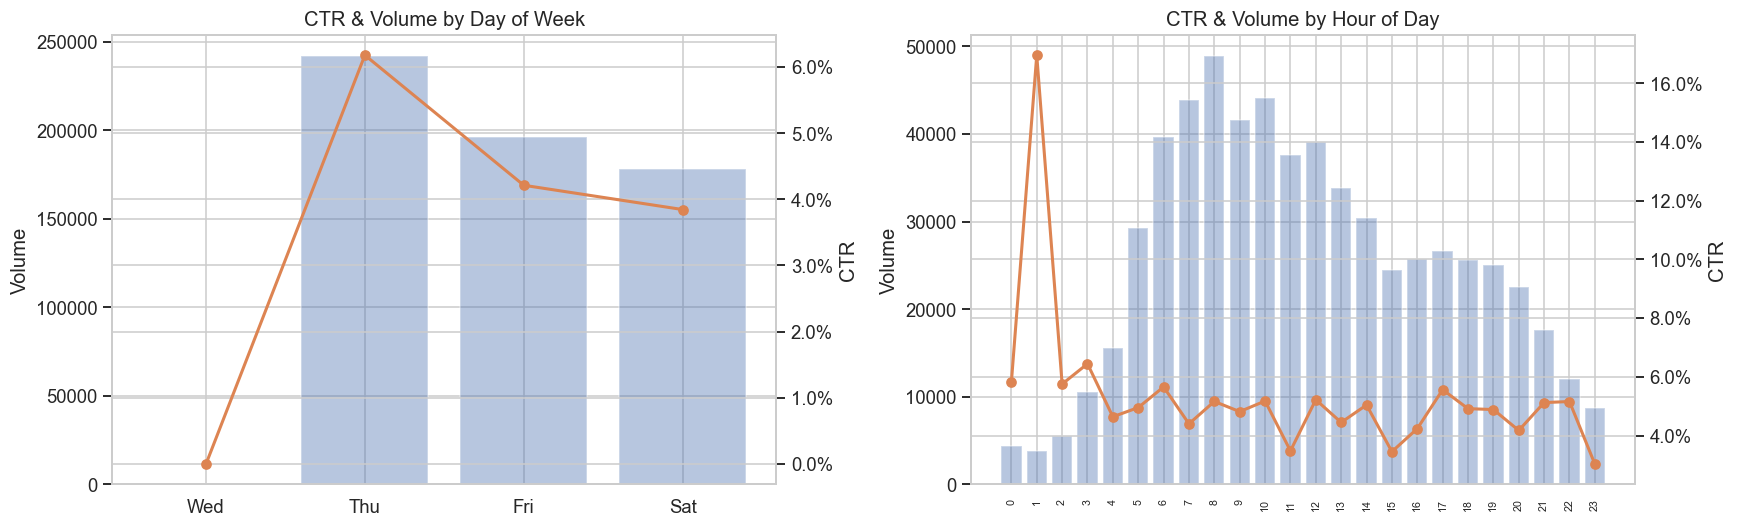

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'f349' in df.columns:
    dow_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
    ctr_dow = df.groupby('f349')['y'].mean(); cnt_dow = df['f349'].value_counts().sort_index()
    ctr_dow.index = [dow_map.get(i,str(i)) for i in ctr_dow.index]
    cnt_dow.index = [dow_map.get(i,str(i)) for i in cnt_dow.index]
    ax2 = axes[0].twinx()
    axes[0].bar(cnt_dow.index, cnt_dow.values, color='#4C72B0', alpha=0.4)
    ax2.plot(ctr_dow.index, ctr_dow.values, color='#DD8452', marker='o', lw=2)
    axes[0].set_title('CTR & Volume by Day of Week'); axes[0].set_ylabel('Volume')
    ax2.set_ylabel('CTR'); ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
else:
    axes[0].set_visible(False)

time_col = next((c for c in ['f350','f168'] if c in df.columns), None)
if time_col:
    df['_hour'] = (df[time_col] // 3600).astype('Int64')
    ctr_h = df.groupby('_hour')['y'].mean(); cnt_h = df.groupby('_hour')['y'].count()
    ax2 = axes[1].twinx()
    axes[1].bar(cnt_h.index.astype(str), cnt_h.values, color='#4C72B0', alpha=0.4)
    ax2.plot(ctr_h.index.astype(str), ctr_h.values, color='#DD8452', marker='o', lw=2)
    axes[1].set_title('CTR & Volume by Hour of Day'); axes[1].set_ylabel('Volume')
    ax2.set_ylabel('CTR'); ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[1].tick_params(axis='x', rotation=90, labelsize=7)
    df.drop(columns=['_hour'], inplace=True)
else:
    axes[1].set_visible(False)

plt.tight_layout(); plt.show()

### 4f. Financial Hardship Scores

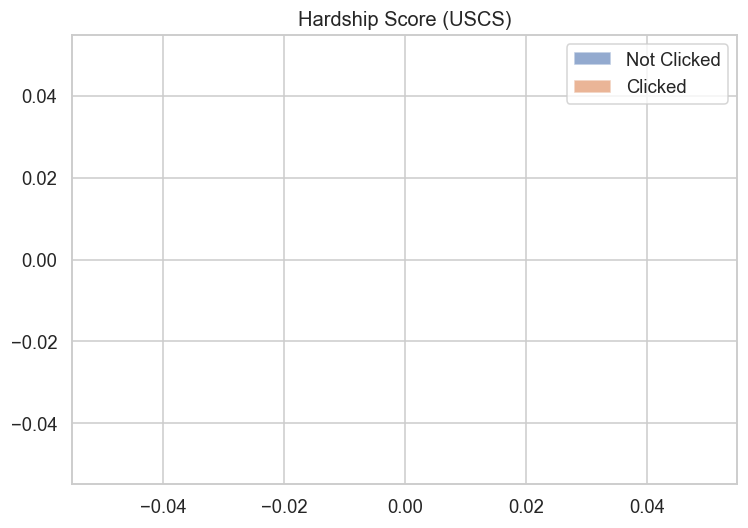

In [23]:
hs_labels = {'f359':'Hardship Score (USCS)','f360':'Hardship Score (GCS)'}
if HARDSHIP_COLS:
    fig, axes = plt.subplots(1, len(HARDSHIP_COLS), figsize=(7*len(HARDSHIP_COLS), 5))
    if len(HARDSHIP_COLS) == 1: axes = [axes]
    for ax, col in zip(axes, HARDSHIP_COLS):
        p1, p99 = df[col].dropna().quantile([0.01, 0.99]); bins = np.linspace(p1, p99, 40)
        ax.hist(df[df['y']==0][col].dropna().clip(p1, p99), bins=bins, alpha=0.6, label='Not Clicked', color='#4C72B0', density=True)
        ax.hist(df[df['y']==1][col].dropna().clip(p1, p99), bins=bins, alpha=0.6, label='Clicked',     color='#DD8452', density=True)
        ax.set_title(hs_labels.get(col,col)); ax.legend()
    plt.tight_layout(); plt.show()

---
## 5. Overall Feature Importance (Correlation Ranking)

In [24]:
feature_cols = [c for c in df.columns if c.startswith('f') and pd.api.types.is_numeric_dtype(df[c])]

corr_results = []
for col in feature_cols:
    series = df[col].fillna(df[col].median())
    if series.nunique() < 2: continue
    r, _ = stats.pointbiserialr(series, df['y'])
    corr_results.append({'feature': col, 'correlation': r, 'abs_corr': abs(r)})

corr_df = pd.DataFrame(corr_results).sort_values('abs_corr', ascending=False)
print('Top 20 features by |correlation| with click:')
print(corr_df.head(20)[['feature','correlation']].to_string(index=False))

Top 20 features by |correlation| with click:
feature  correlation
   f366     0.484186
   f363     0.421947
   f365     0.403580
   f132     0.309123
   f134     0.308516
   f137     0.306086
   f362     0.290273
   f138     0.289432
   f130     0.288492
   f131     0.270498
   f133     0.259831
    f95     0.152617
    f94     0.144624
   f108     0.127571
    f31     0.121695
   f208     0.115689
   f223    -0.113725
    f28     0.110022
   f103     0.105981
   f201     0.105844


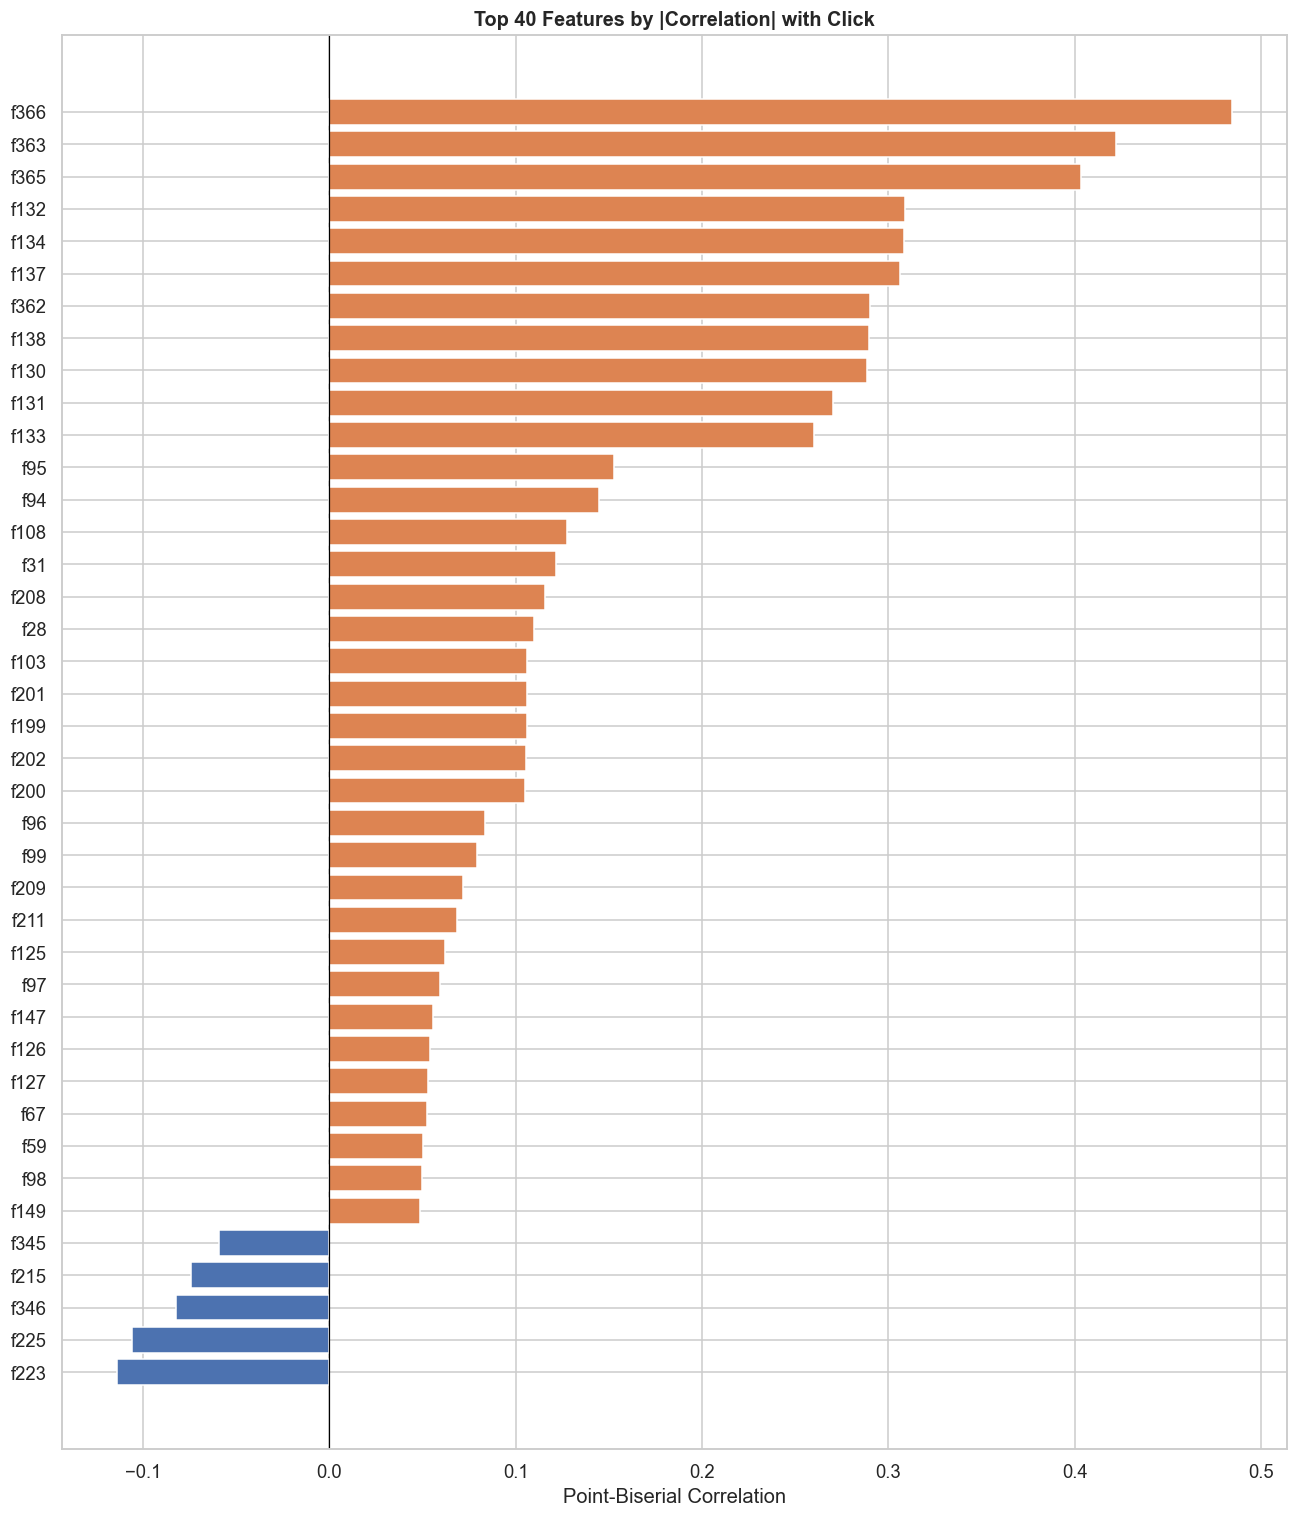

In [25]:
top40 = corr_df.head(40).sort_values('correlation')
fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(top40['feature'], top40['correlation'],
        color=['#DD8452' if v>0 else '#4C72B0' for v in top40['correlation']])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 40 Features by |Correlation| with Click', fontsize=13, fontweight='bold')
ax.set_xlabel('Point-Biserial Correlation')
plt.tight_layout(); plt.show()

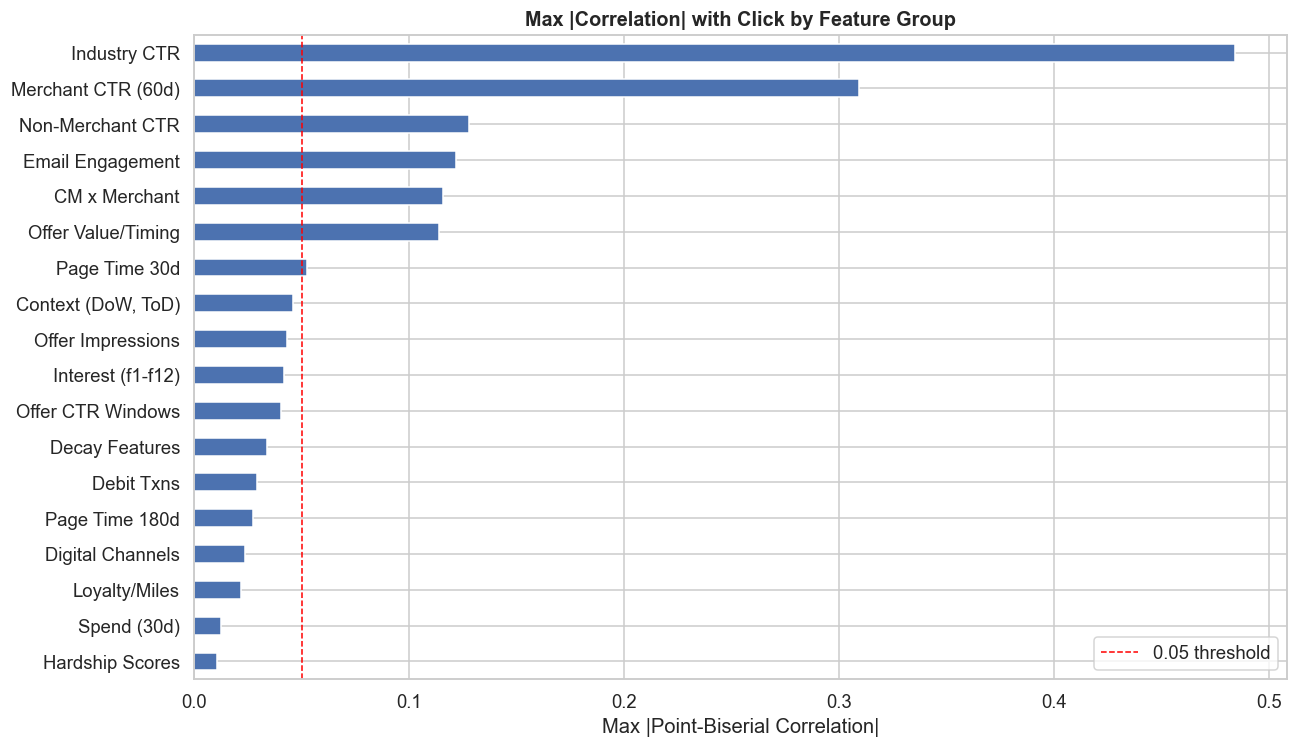

In [26]:
group_map = {
    'Interest (f1-f12)':    INTEREST_COLS,
    'Digital Channels':     DIGITAL_CHANNEL_COLS,
    'Email Engagement':     EMAIL_COLS,
    'Page Time 30d':        PAGE_TIME_30D,
    'Page Time 180d':       PAGE_TIME_180D,
    'Non-Merchant CTR':     NON_MERCH_CTR_COLS,
    'Merchant CTR (60d)':   MERCH_CTR_COLS,
    'Spend (30d)':          SPEND_30D_COLS,
    'Loyalty/Miles':        LOYALTY_NUM_COLS,
    'Debit Txns':           DEBIT_TXN_COLS,
    'Offer CTR Windows':    OFFER_CTR_COLS,
    'Offer Impressions':    OFFER_IMP_COLS,
    'Offer Value/Timing':   OFFER_MERIT_COLS,
    'Decay Features':       DECAY_COLS,
    'Industry CTR':         INDUSTRY_COLS,
    'CM x Merchant':        MERCH_CM_COLS,
    'Context (DoW, ToD)':   CONTEXT_COLS,
    'Hardship Scores':      HARDSHIP_COLS,
}

feat_set = set(corr_df['feature'])
group_max = {g: corr_df[corr_df['feature'].isin([c for c in cols if c in feat_set])]['abs_corr'].max()
             for g, cols in group_map.items() if cols}
group_max = {g: v for g, v in group_max.items() if not (isinstance(v, float) and np.isnan(v))}

fig, ax = plt.subplots(figsize=(12, 7))
pd.Series(group_max).sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Max |Correlation| with Click by Feature Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Max |Point-Biserial Correlation|')
ax.axvline(0.05, color='red', lw=1, linestyle='--', label='0.05 threshold')
ax.legend(); plt.tight_layout(); plt.show()

---
## 6. Summary of Key EDA Findings

### Dataset
- 616,602 rows × 316 columns; highly imbalanced target (~low single-digit CTR)
- Each row is a (customer, offer) impression event

### Top Signals by Feature Group
| Group | Key Insight |
|---|---|
| **Industry CTR (f361–f366)** | Highest-signal group — f366 (customer 6mo CTR on relevant offers) and f363 (industry CTR 180d) strongly predict click |
| **Merchant CTR (f137, f138)** | Customer's aggregate merchant CTR last 30–60d is a strong predictor |
| **CM × Merchant prior clicks** | Prior clicks on same-merchant offers (f208–f210) are informative |
| **Offer CTR windows** | Offers with rising short-window CTR momentum are more clickable |
| **Interest × Category** | Customers with high interest scores for a category more likely click matching offers |
| **Offer value** | Discount/dollar and MR points matter but less than behavioral history |
| **Context** | Evening hours & weekdays show higher CTR than early morning & weekends |
| **Loyalty** | Award miles availability and elite status are moderately predictive |

### Feature Engineering Priorities
1. Within-customer relative ranking (MAP@7 is a ranking-within-customer metric)
2. Customer–offer category alignment (interest × OHE category)
3. CTR momentum ratios (short/long window trend direction)
4. Sequential session signals (session position, time since last click)